<a href="https://colab.research.google.com/github/Akashgks/Ship_Hull_Inspection_MambaSeg_Model/blob/main/PEP_MambaSeg_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import shutil
from google.colab import drive

MOUNT_POINT = "/content/drive"

# Colab already confirmed Drive is NOT mounted.
# Remove the stale local mount directory.
if os.path.exists(MOUNT_POINT):
    print("Removing stale local mountpoint...")
    shutil.rmtree(MOUNT_POINT)

print("Mounting Google Drive...")
drive.mount(MOUNT_POINT)

print("\n" + "=" * 60)
print("DRIVE CHECK")
print("=" * 60)

assert os.path.isdir("/content/drive/MyDrive"), \
    "Google Drive mount failed."

print("✓ Google Drive mounted")
print("✓ MyDrive exists")
print("=" * 60)

Mounting Google Drive...
Mounted at /content/drive

DRIVE CHECK
✓ Google Drive mounted
✓ MyDrive exists


In [16]:
import os
import torch

# ============================================================
# MAMBASEG — PROJECT PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")
LOGS_DIR = os.path.join(PROJECT_DIR, "logs")
CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")

for directory in [
    CHECKPOINT_DIR,
    RESULTS_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
    CONFIG_DIR
]:
    os.makedirs(directory, exist_ok=True)

# Dataset remains unchanged
DATASET_DIR = (
    "/content/drive/MyDrive/PEP_SEG_DATA/"
    "LIACi_dataset_pretty/preprocessed_512"
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_miou.pth"
)

LATEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "latest.pth"
)

print("=" * 65)
print("MAMBASEG — PROJECT SETUP")
print("=" * 65)

print("Project     :", PROJECT_DIR)
print("Dataset     :", DATASET_DIR)
print("Checkpoints :", CHECKPOINT_DIR)
print("Results     :", RESULTS_DIR)
print("Predictions :", PREDICTIONS_DIR)
print("Logs        :", LOGS_DIR)

print("\nCUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

print("=" * 65)
print(" MAMBASEG WORKSPACE READY")
print("=" * 65)

MAMBASEG — PROJECT SETUP
Project     : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model
Dataset     : /content/drive/MyDrive/PEP_SEG_DATA/LIACi_dataset_pretty/preprocessed_512
Checkpoints : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/checkpoints
Results     : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/results
Predictions : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/predictions
Logs        : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/logs

CUDA available : True
GPU            : Tesla T4
 MAMBASEG WORKSPACE READY


In [17]:
# ============================================================
# MAMBASEG-LIACI — ENVIRONMENT PREFLIGHT
# ============================================================

import os
import sys
import json
import torch
import platform

PROJECT_DIR = "/content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")
LOGS_DIR = os.path.join(PROJECT_DIR, "logs")
CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")

DATASET_DIR = (
    "/content/drive/MyDrive/PEP_SEG_DATA/"
    "LIACi_dataset_pretty/preprocessed_512"
)

for path in [
    CHECKPOINT_DIR,
    RESULTS_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
    CONFIG_DIR
]:
    os.makedirs(path, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("MAMBASEG-LIACI — ENVIRONMENT PREFLIGHT")
print("=" * 70)

print("Python          :", sys.version.split()[0])
print("PyTorch         :", torch.__version__)
print("CUDA toolkit    :", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())
print("Device          :", device)

if torch.cuda.is_available():

    props = torch.cuda.get_device_properties(0)

    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU VRAM        :",
        f"{props.total_memory / 1024**3:.2f} GB"
    )

print()
print("Project exists  :", os.path.isdir(PROJECT_DIR))
print("Dataset exists  :", os.path.isdir(DATASET_DIR))

assert torch.cuda.is_available(), "GPU runtime is required."
assert os.path.isdir(PROJECT_DIR), "MambaSeg project folder missing."
assert os.path.isdir(DATASET_DIR), "LIACi processed dataset missing."

print("=" * 70)
print("✓ ENVIRONMENT PREFLIGHT PASSED")
print("=" * 70)

MAMBASEG-LIACI — ENVIRONMENT PREFLIGHT
Python          : 3.13.15
PyTorch         : 2.11.0+cu130
CUDA toolkit    : 13.0
CUDA available  : True
Device          : cuda
GPU             : Tesla T4
GPU VRAM        : 14.56 GB

Project exists  : True
Dataset exists  : True
✓ ENVIRONMENT PREFLIGHT PASSED


In [18]:
# ============================================================
# CELL 2 — LIACI DATASET INTEGRITY CHECK
# ============================================================

import os
import cv2
import numpy as np
from collections import Counter

EXPECTED_COUNTS = {
    "train": 1233,
    "val": 137,
    "test": 191
}

NUM_CLASSES = 11

CLASS_NAMES = [
    "Void",
    "Ship hull",
    "Marine growth",
    "Anode",
    "Overboard valve",
    "Propeller",
    "Paint peel",
    "Bilge keel",
    "Defect",
    "Corrosion",
    "Sea chest grating"
]

print("=" * 75)
print("LIACI DATASET — INTEGRITY CHECK")
print("=" * 75)

split_info = {}

for split in ["train", "val", "test"]:

    image_dir = os.path.join(
        DATASET_DIR, "images", split
    )

    mask_dir = os.path.join(
        DATASET_DIR, "masks", split
    )

    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    mask_files = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    ])

    # ----------------------------------------
    # Match by filename stem
    # ----------------------------------------

    image_map = {
        os.path.splitext(f)[0]: f
        for f in image_files
    }

    mask_map = {
        os.path.splitext(f)[0]: f
        for f in mask_files
    }

    image_names = set(image_map.keys())
    mask_names = set(mask_map.keys())

    missing_masks = sorted(
        image_names - mask_names
    )

    missing_images = sorted(
        mask_names - image_names
    )

    common = sorted(
        image_names & mask_names
    )

    # ----------------------------------------
    # Assertions
    # ----------------------------------------

    assert len(common) == EXPECTED_COUNTS[split], (
        f"{split}: expected "
        f"{EXPECTED_COUNTS[split]} pairs, "
        f"found {len(common)}"
    )

    assert len(missing_masks) == 0, (
        f"{split}: images without masks: "
        f"{missing_masks[:10]}"
    )

    assert len(missing_images) == 0, (
        f"{split}: masks without images: "
        f"{missing_images[:10]}"
    )

    # ----------------------------------------
    # Inspect representative sample
    # ----------------------------------------

    sample_name = common[0]

    image = cv2.imread(
        os.path.join(
            image_dir,
            image_map[sample_name]
        )
    )

    mask = cv2.imread(
        os.path.join(
            mask_dir,
            mask_map[sample_name]
        ),
        cv2.IMREAD_GRAYSCALE
    )

    assert image is not None
    assert mask is not None

    assert image.shape[:2] == (512, 512), (
        f"{split}: unexpected image size "
        f"{image.shape}"
    )

    assert mask.shape == (512, 512), (
        f"{split}: unexpected mask size "
        f"{mask.shape}"
    )

    assert mask.min() >= 0
    assert mask.max() < NUM_CLASSES, (
        f"{split}: invalid class index "
        f"{mask.max()}"
    )

    split_info[split] = {
        "pairs": len(common),
        "sample": sample_name,
        "classes": np.unique(mask).tolist()
    }

    print(f"\n{split.upper()}")
    print("-" * 40)

    print(
        "Image files       :",
        len(image_files)
    )

    print(
        "Mask files        :",
        len(mask_files)
    )

    print(
        "Matched pairs     :",
        len(common)
    )

    print(
        "Missing masks     :",
        len(missing_masks)
    )

    print(
        "Missing images    :",
        len(missing_images)
    )

    print(
        "Sample image shape:",
        image.shape
    )

    print(
        "Sample mask shape :",
        mask.shape
    )

    print(
        "Sample classes    :",
        np.unique(mask)
    )


print("\n" + "=" * 75)
print("EXPECTED DATASET TOTALS")
print("=" * 75)

total = sum(
    info["pairs"]
    for info in split_info.values()
)

print(
    f"Train : {split_info['train']['pairs']}"
)

print(
    f"Val   : {split_info['val']['pairs']}"
)

print(
    f"Test  : {split_info['test']['pairs']}"
)

print(f"Total : {total}")

assert total == 1561

print("=" * 75)
print("✓ DATASET INTEGRITY CHECK PASSED")
print("=" * 75)

LIACI DATASET — INTEGRITY CHECK

TRAIN
----------------------------------------
Image files       : 1233
Mask files        : 1233
Matched pairs     : 1233
Missing masks     : 0
Missing images    : 0
Sample image shape: (512, 512, 3)
Sample mask shape : (512, 512)
Sample classes    : [0 1 3 5 6 7]

VAL
----------------------------------------
Image files       : 137
Mask files        : 137
Matched pairs     : 137
Missing masks     : 0
Missing images    : 0
Sample image shape: (512, 512, 3)
Sample mask shape : (512, 512)
Sample classes    : [0 1 5 6 8]

TEST
----------------------------------------
Image files       : 191
Mask files        : 191
Matched pairs     : 191
Missing masks     : 0
Missing images    : 0
Sample image shape: (512, 512, 3)
Sample mask shape : (512, 512)
Sample classes    : [0 1 7]

EXPECTED DATASET TOTALS
Train : 1233
Val   : 137
Test  : 191
Total : 1561
✓ DATASET INTEGRITY CHECK PASSED


In [19]:
# ============================================================
# CELL 3 — CREATE OUR OWN MAMBASEG-INSPIRED PROJECT
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model"

folders = {
    "checkpoints": os.path.join(PROJECT_DIR, "checkpoints"),
    "results": os.path.join(PROJECT_DIR, "results"),
    "predictions": os.path.join(PROJECT_DIR, "predictions"),
    "logs": os.path.join(PROJECT_DIR, "logs"),
    "configs": os.path.join(PROJECT_DIR, "configs"),
}

print("=" * 70)
print("OUR MAMBA VISION SEGMENTATION PROJECT")
print("=" * 70)

for name, path in folders.items():

    os.makedirs(path, exist_ok=True)

    assert os.path.isdir(path)

    print(f"{name:15s}: ✓ {path}")

print("=" * 70)
print("✓ PROJECT STRUCTURE READY")
print("=" * 70)

OUR MAMBA VISION SEGMENTATION PROJECT
checkpoints    : ✓ /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/checkpoints
results        : ✓ /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/results
predictions    : ✓ /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/predictions
logs           : ✓ /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/logs
configs        : ✓ /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/configs
✓ PROJECT STRUCTURE READY


2D Mamba SS

In [53]:
# ============================================================
# CELL 4 — CUSTOM 2D SELECTIVE STATE-SPACE BLOCK
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class SelectiveScan1D(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

        self.selective_proj = nn.Linear(
            dim,
            dim * 3
        )

        self.A_log = nn.Parameter(
            torch.zeros(dim)
        )

        self.out_proj = nn.Linear(
            dim,
            dim
        )

    def forward(self, x):
        """
        x: [B, L, C]

        Sensitive recurrent SSM calculations are forced
        to FP32 even when the surrounding model uses AMP.
        """

        original_dtype = x.dtype

        # ----------------------------------------------------
        # Disable autocast ONLY for the sensitive SSM section
        # ----------------------------------------------------

        with torch.amp.autocast(
            "cuda",
            enabled=False
        ):

            x_fp32 = x.float()

            # Linear weights are model FP32 parameters.
            projected = self.selective_proj(
                x_fp32
            )

            delta, B_gate, C_gate = (
                projected.chunk(
                    3,
                    dim=-1
                )
            )

            # Positive step size
            delta = F.softplus(
                delta
            )

            B_gate = torch.sigmoid(
                B_gate
            )

            C_gate = torch.sigmoid(
                C_gate
            )

            # Stable negative state decay
            A = -torch.exp(
                self.A_log.float()
            )

            batch_size, seq_len, channels = (
                x_fp32.shape
            )

            state = torch.zeros(
                batch_size,
                channels,
                device=x.device,
                dtype=torch.float32
            )

            outputs = []

            for t in range(seq_len):

                dt = delta[:, t]

                # dt > 0 and A < 0,
                # therefore exponent should be <= 0.
                exponent = dt * A

                # Extra numerical guard.
                exponent = torch.clamp(
                    exponent,
                    min=-30.0,
                    max=0.0
                )

                decay = torch.exp(
                    exponent
                )

                input_write = (
                    (1.0 - decay)
                    * B_gate[:, t]
                    * x_fp32[:, t]
                )

                state = (
                    decay * state
                    + input_write
                )

                y_t = (
                    C_gate[:, t]
                    * state
                )

                outputs.append(
                    y_t
                )

            y = torch.stack(
                outputs,
                dim=1
            )

            y = self.out_proj(
                y
            )

        # Return to surrounding AMP dtype if needed
        return y.to(original_dtype)


print("✓ FP32-stable SelectiveScan1D defined")

class VisionSelectiveScan2D(nn.Module):
    """
    Four-direction 2D selective state-space scan.

    Directions:
        1. left -> right
        2. right -> left
        3. top -> bottom
        4. bottom -> top
    """

    def __init__(self, dim):
        super().__init__()

        self.dim = dim

        # Shared scan operator.
        # Direction-specific information comes from
        # different sequence orientations.
        self.scan = SelectiveScan1D(dim)

        # Learn how important each direction is.
        self.direction_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(
                dim,
                dim // 4,
                kernel_size=1
            ),
            nn.GELU(),
            nn.Conv2d(
                dim // 4,
                4,
                kernel_size=1
            )
        )

        self.output_projection = nn.Conv2d(
            dim,
            dim,
            kernel_size=1
        )

    def forward(self, x):

        B, C, H, W = x.shape

        assert C == self.dim

        # ==========================================
        # HORIZONTAL
        # ==========================================

        horizontal = (
            x.permute(0, 2, 3, 1)
             .contiguous()
             .reshape(B * H, W, C)
        )

        # Left -> Right
        lr = self.scan(horizontal)

        # Right -> Left
        rl = torch.flip(
            horizontal,
            dims=[1]
        )

        rl = self.scan(rl)

        rl = torch.flip(
            rl,
            dims=[1]
        )

        # Restore spatial shape
        lr = (
            lr.reshape(B, H, W, C)
              .permute(0, 3, 1, 2)
              .contiguous()
        )

        rl = (
            rl.reshape(B, H, W, C)
              .permute(0, 3, 1, 2)
              .contiguous()
        )

        # ==========================================
        # VERTICAL
        # ==========================================

        vertical = (
            x.permute(0, 3, 2, 1)
             .contiguous()
             .reshape(B * W, H, C)
        )

        # Top -> Bottom
        tb = self.scan(vertical)

        # Bottom -> Top
        bt = torch.flip(
            vertical,
            dims=[1]
        )

        bt = self.scan(bt)

        bt = torch.flip(
            bt,
            dims=[1]
        )

        # Restore spatial shape
        tb = (
            tb.reshape(B, W, H, C)
              .permute(0, 3, 2, 1)
              .contiguous()
        )

        bt = (
            bt.reshape(B, W, H, C)
              .permute(0, 3, 2, 1)
              .contiguous()
        )

        # ==========================================
        # DIRECTION ATTENTION
        # ==========================================

        weights = self.direction_gate(x)

        weights = torch.softmax(
            weights,
            dim=1
        )

        w_lr = weights[:, 0:1]
        w_rl = weights[:, 1:2]
        w_tb = weights[:, 2:3]
        w_bt = weights[:, 3:4]

        fused = (
            w_lr * lr
            + w_rl * rl
            + w_tb * tb
            + w_bt * bt
        )

        return self.output_projection(fused)


class VisionSSMBlock(nn.Module):


    def __init__(
        self,
        dim,
        mlp_ratio=2.0
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            1,
            dim
        )

        # Local spatial information
        self.local_conv = nn.Conv2d(
            dim,
            dim,
            kernel_size=3,
            padding=1,
            groups=dim
        )

        self.scan = VisionSelectiveScan2D(
            dim
        )

        self.norm2 = nn.GroupNorm(
            1,
            dim
        )

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.mlp = nn.Sequential(

            nn.Conv2d(
                dim,
                hidden_dim,
                kernel_size=1
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden_dim,
                dim,
                kernel_size=1
            )
        )

    def forward(self, x):

        residual = x

        y = self.norm1(x)

        y = self.local_conv(y)

        y = F.gelu(y)

        y = self.scan(y)

        x = residual + y

        x = x + self.mlp(
            self.norm2(x)
        )

        return x

✓ FP32-stable SelectiveScan1D defined


In [5]:
# ============================================================
# CELL 7 — VISION SSM GPU SPEED + VRAM BENCHMARK
# ============================================================

import time
import torch

assert torch.cuda.is_available()

device = torch.device("cuda")

print("=" * 78)
print("VISION SSM — GPU PERFORMANCE BENCHMARK")
print("=" * 78)

DIM = 64
BATCH_SIZE = 2

block = VisionSSMBlock(
    dim=DIM
).to(device)

block.eval()

total_params = sum(
    p.numel()
    for p in block.parameters()
)

print(f"Device     : {torch.cuda.get_device_name(0)}")
print(f"Channels   : {DIM}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Parameters : {total_params:,}")
print("-" * 78)

sizes = [16, 32, 64, 128]

results = []

for size in sizes:

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    x = torch.randn(
        BATCH_SIZE,
        DIM,
        size,
        size,
        device=device
    )

    # -----------------------------
    # Warm-up
    # -----------------------------
    with torch.no_grad():
        _ = block(x)

    torch.cuda.synchronize()

    # -----------------------------
    # Timed forward
    # -----------------------------
    start = time.perf_counter()

    with torch.no_grad():
        y = block(x)

    torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    peak_memory = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    finite = torch.isfinite(y).all().item()

    assert y.shape == x.shape
    assert finite

    results.append(
        (size, elapsed, peak_memory)
    )

    print(
        f"{size:3d}×{size:<3d} | "
        f"time = {elapsed:7.4f} sec | "
        f"peak VRAM = {peak_memory:6.3f} GB | "
        f"✓"
    )

    del x, y


print("-" * 78)

print("✓ ALL GPU FORWARD TESTS PASSED")

print("=" * 78)

VISION SSM — GPU PERFORMANCE BENCHMARK
Device     : Tesla T4
Channels   : 64
Batch size : 2
Parameters : 39,444
------------------------------------------------------------------------------
 16×16  | time =  0.0100 sec | peak VRAM =  0.011 GB | ✓
 32×32  | time =  0.0317 sec | peak VRAM =  0.018 GB | ✓
 64×64  | time =  0.0572 sec | peak VRAM =  0.044 GB | ✓
128×128 | time =  0.0907 sec | peak VRAM =  0.150 GB | ✓
------------------------------------------------------------------------------
✓ ALL GPU FORWARD TESTS PASSED


In [6]:
# ============================================================
# CELL 8 — GPU FORWARD + BACKWARD BENCHMARK
# ============================================================

import time
import torch

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

block = VisionSSMBlock(
    dim=64
).to(device)

block.train()

x = torch.randn(
    2,
    64,
    64,
    64,
    device=device,
    requires_grad=True
)

print("=" * 78)
print("VISION SSM — TRAINING BENCHMARK")
print("=" * 78)

torch.cuda.synchronize()

start = time.perf_counter()

y = block(x)

loss = y.square().mean()

loss.backward()

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

peak_memory = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

assert torch.isfinite(loss)
assert x.grad is not None
assert torch.isfinite(x.grad).all()

print(f"Input           : {tuple(x.shape)}")
print(f"Output          : {tuple(y.shape)}")
print(f"Loss            : {loss.item():.6f}")
print(f"Forward+Backward: {elapsed:.4f} sec")
print(f"Peak GPU VRAM   : {peak_memory:.3f} GB")

print("=" * 78)
print("✓ GPU BACKWARD TEST PASSED")
print("=" * 78)

del block, x, y, loss

torch.cuda.empty_cache()

VISION SSM — TRAINING BENCHMARK
Input           : (2, 64, 64, 64)
Output          : (2, 64, 64, 64)
Loss            : 1.058158
Forward+Backward: 0.5351 sec
Peak GPU VRAM   : 0.148 GB
✓ GPU BACKWARD TEST PASSED


Vision SSM segmentation

In [7]:
# ============================================================
# CELL 9 — FULL VISION-SSM SEGMENTATION MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvNormAct(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                1,
                out_channels
            ),

            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class DownsampleBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.down = ConvNormAct(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=2,
            padding=1
        )

    def forward(self, x):
        return self.down(x)


class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):
        super().__init__()

        self.conv1 = ConvNormAct(
            in_channels + skip_channels,
            out_channels
        )

        self.conv2 = ConvNormAct(
            out_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.conv1(x)
        x = self.conv2(x)

        return x


class VisionSSMSegmenter(nn.Module):

    def __init__(
        self,
        num_classes=11
    ):
        super().__init__()

        # ====================================================
        # STEM
        # 512 -> 256 -> 128
        # ====================================================

        self.stem = nn.Sequential(

            ConvNormAct(
                3,
                48,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            ConvNormAct(
                48,
                96,
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        # ====================================================
        # ENCODER
        # ====================================================

        # 128 -> 64
        self.down1 = DownsampleBlock(
            96,
            192
        )

        self.encoder1 = VisionSSMBlock(
            dim=192
        )

        # 64 -> 32
        self.down2 = DownsampleBlock(
            192,
            384
        )

        self.encoder2 = VisionSSMBlock(
            dim=384
        )

        # 32 -> 16
        self.down3 = DownsampleBlock(
            384,
            512
        )

        self.bottleneck = VisionSSMBlock(
            dim=512
        )

        # ====================================================
        # DECODER
        # ====================================================

        self.decoder3 = DecoderBlock(
            in_channels=512,
            skip_channels=384,
            out_channels=384
        )

        self.decoder2 = DecoderBlock(
            in_channels=384,
            skip_channels=192,
            out_channels=192
        )

        self.decoder1 = DecoderBlock(
            in_channels=192,
            skip_channels=96,
            out_channels=96
        )

        # ====================================================
        # SEGMENTATION HEAD
        # ====================================================

        self.segmentation_head = nn.Sequential(

            ConvNormAct(
                96,
                64
            ),

            nn.Conv2d(
                64,
                num_classes,
                kernel_size=1
            )
        )

        self.num_classes = num_classes


    def forward(self, x):

        input_size = x.shape[-2:]

        # -----------------------
        # Stem / Skip 1
        # -----------------------

        skip1 = self.stem(x)
        # [B,96,128,128]

        # -----------------------
        # Encoder 1 / Skip 2
        # -----------------------

        x = self.down1(skip1)
        x = self.encoder1(x)

        skip2 = x
        # [B,192,64,64]

        # -----------------------
        # Encoder 2 / Skip 3
        # -----------------------

        x = self.down2(x)
        x = self.encoder2(x)

        skip3 = x
        # [B,384,32,32]

        # -----------------------
        # Bottleneck
        # -----------------------

        x = self.down3(x)
        x = self.bottleneck(x)
        # [B,512,16,16]

        # -----------------------
        # Decoder
        # -----------------------

        x = self.decoder3(
            x,
            skip3
        )

        x = self.decoder2(
            x,
            skip2
        )

        x = self.decoder1(
            x,
            skip1
        )

        # -----------------------
        # Head
        # -----------------------

        x = self.segmentation_head(x)

        x = F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return x


print("✓ VisionSSMSegmenter class created")

✓ VisionSSMSegmenter class created


Forward Test

In [9]:
# ============================================================
# CELL 10 — FULL MODEL FORWARD TEST
# ============================================================

import time
import torch

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

device = torch.device("cuda")

model = VisionSSMSegmenter(
    num_classes=11
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 75)
print("FULL VISION-SSM SEGMENTATION MODEL")
print("=" * 75)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

x = torch.randn(
    1,
    3,
    512,
    512,
    device=device
)

model.eval()

# Warmup
with torch.no_grad():
    _ = model(x)

torch.cuda.synchronize()

start = time.perf_counter()

with torch.no_grad():
    output = model(x)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

peak_vram = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

print()
print("Input shape :", tuple(x.shape))
print("Output shape:", tuple(output.shape))
print(f"Forward time: {elapsed:.4f} sec")
print(f"Peak VRAM   : {peak_vram:.3f} GB")

assert output.shape == (
    1,
    11,
    512,
    512
)

assert torch.isfinite(
    output
).all()

print("=" * 75)
print(" FULL MODEL FORWARD TEST PASSED")
print(" 11-CLASS OUTPUT CONFIRMED")
print(" NO NaN/Inf")
print("=" * 75)

FULL VISION-SSM SEGMENTATION MODEL
Total parameters    : 12,941,719
Trainable parameters: 12,941,719

Input shape : (1, 3, 512, 512)
Output shape: (1, 11, 512, 512)
Forward time: 0.1063 sec
Peak VRAM   : 0.137 GB
 FULL MODEL FORWARD TEST PASSED
 11-CLASS OUTPUT CONFIRMED
 NO NaN/Inf


In [11]:
# ============================================================
# CELL 11 — FULL MODEL SEGMENTATION BACKWARD TEST
# ============================================================

import time
import torch
import torch.nn as nn

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model.train()

x = torch.randn(
    1,
    3,
    512,
    512,
    device=device
)

target = torch.randint(
    low=0,
    high=11,
    size=(1, 512, 512),
    device=device,
    dtype=torch.long
)

criterion_test = nn.CrossEntropyLoss()

model.zero_grad(
    set_to_none=True
)

torch.cuda.synchronize()

start = time.perf_counter()

logits = model(x)

loss = criterion_test(
    logits,
    target
)

loss.backward()

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

peak_vram = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

# ------------------------------------------------------------
# Gradient validation
# ------------------------------------------------------------

trainable = 0
with_gradient = 0
bad_gradients = []

for name, parameter in model.named_parameters():

    if parameter.requires_grad:

        trainable += 1

        if parameter.grad is not None:

            with_gradient += 1

            if not torch.isfinite(
                parameter.grad
            ).all():

                bad_gradients.append(name)


print("=" * 75)
print("FULL MODEL — SEGMENTATION BACKWARD TEST")
print("=" * 75)

print(f"Loss                  : {loss.item():.6f}")
print(f"Forward + backward    : {elapsed:.4f} sec")
print(f"Peak VRAM             : {peak_vram:.3f} GB")
print(f"Trainable tensors     : {trainable}")
print(f"Tensors with gradient : {with_gradient}")
print(f"Bad gradient tensors  : {len(bad_gradients)}")

assert torch.isfinite(loss)

assert with_gradient == trainable, (
    f"{trainable-with_gradient} parameters "
    "did not receive gradients."
)

assert len(bad_gradients) == 0, (
    f"Invalid gradients: {bad_gradients}"
)

print("=" * 75)
print(" FULL BACKPROPAGATION PASSED")
print(" ALL PARAMETERS RECEIVE GRADIENTS")
print(" NO NaN/Inf GRADIENTS")
print("=" * 75)

del x, target, logits, loss

model.zero_grad(set_to_none=True)

torch.cuda.empty_cache()

FULL MODEL — SEGMENTATION BACKWARD TEST
Loss                  : 2.460386
Forward + backward    : 0.4287 sec
Peak VRAM             : 0.618 GB
Trainable tensors     : 101
Tensors with gradient : 101
Bad gradient tensors  : 0
 FULL BACKPROPAGATION PASSED
 ALL PARAMETERS RECEIVE GRADIENTS
 NO NaN/Inf GRADIENTS


In [12]:
# ============================================================
# CELL 12 — BATCH SIZE STRESS TEST
# ============================================================

import gc
import time
import torch
import torch.nn as nn

device = torch.device("cuda")
criterion_test = nn.CrossEntropyLoss()

batch_sizes = [2, 4, 8]

print("=" * 82)
print("BATCH SIZE — TRAINING STRESS TEST")
print("=" * 82)

results = []

for batch_size in batch_sizes:

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    try:

        model = VisionSSMSegmenter(
            num_classes=11
        ).to(device)

        model.train()

        x = torch.randn(
            batch_size,
            3,
            512,
            512,
            device=device
        )

        target = torch.randint(
            0,
            11,
            (batch_size, 512, 512),
            device=device,
            dtype=torch.long
        )

        model.zero_grad(set_to_none=True)

        # ----------------------------
        # Warm-up
        # ----------------------------

        logits = model(x)

        loss = criterion_test(
            logits,
            target
        )

        loss.backward()

        model.zero_grad(set_to_none=True)

        del logits, loss

        torch.cuda.synchronize()

        # ----------------------------
        # Actual timed run
        # ----------------------------

        torch.cuda.reset_peak_memory_stats()

        start = time.perf_counter()

        logits = model(x)

        loss = criterion_test(
            logits,
            target
        )

        loss.backward()

        torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

        peak_vram = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        images_per_second = (
            batch_size / elapsed
        )

        finite_loss = torch.isfinite(
            loss
        ).item()

        assert finite_loss

        print(
            f"Batch {batch_size:2d} | "
            f"{elapsed:6.3f} sec | "
            f"{peak_vram:6.3f} GB | "
            f"{images_per_second:6.2f} img/s | ✓"
        )

        results.append({
            "batch": batch_size,
            "time": elapsed,
            "vram": peak_vram,
            "throughput": images_per_second,
            "status": "PASS"
        })

        del model
        del x
        del target
        del logits
        del loss

    except torch.cuda.OutOfMemoryError:

        print(
            f"Batch {batch_size:2d} | "
            f"CUDA OUT OF MEMORY "
        )

        results.append({
            "batch": batch_size,
            "status": "OOM"
        })

    finally:

        gc.collect()
        torch.cuda.empty_cache()


print("-" * 82)

print("\nSUMMARY")

for result in results:

    if result["status"] == "PASS":

        print(
            f"Batch {result['batch']:2d}: "
            f"{result['vram']:.3f} GB, "
            f"{result['throughput']:.2f} img/s"
        )

    else:

        print(
            f"Batch {result['batch']:2d}: OOM"
        )

print("=" * 82)

BATCH SIZE — TRAINING STRESS TEST
Batch  2 |  0.343 sec |  1.125 GB |   5.83 img/s | ✓
Batch  4 |  0.652 sec |  2.155 GB |   6.13 img/s | ✓
Batch  8 |  1.093 sec |  4.625 GB |   7.32 img/s | ✓
----------------------------------------------------------------------------------

SUMMARY
Batch  2: 1.125 GB, 5.83 img/s
Batch  4: 2.155 GB, 6.13 img/s
Batch  8: 4.625 GB, 7.32 img/s


Dataset on PyTorch

In [13]:
# ============================================================
# CELL 13 — LIACI PYTORCH DATASET
# ============================================================

import os
import cv2
import numpy as np
import torch

from torch.utils.data import Dataset


class LIACiDataset(Dataset):

    def __init__(
        self,
        base_dir,
        split
    ):

        self.base_dir = base_dir
        self.split = split

        self.image_dir = os.path.join(
            base_dir,
            "images",
            split
        )

        self.mask_dir = os.path.join(
            base_dir,
            "masks",
            split
        )

        image_files = sorted(
            os.listdir(self.image_dir)
        )

        mask_files = sorted(
            os.listdir(self.mask_dir)
        )

        image_map = {
            os.path.splitext(f)[0]: f
            for f in image_files
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        }

        mask_map = {
            os.path.splitext(f)[0]: f
            for f in mask_files
            if f.lower().endswith(".png")
        }

        common_names = sorted(
            set(image_map.keys())
            &
            set(mask_map.keys())
        )

        self.samples = [
            (
                image_map[name],
                mask_map[name]
            )
            for name in common_names
        ]

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No paired samples found for {split}"
            )

        print(
            f"{split.upper():5s} dataset: "
            f"{len(self.samples)} paired samples"
        )


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, idx):

        image_name, mask_name = (
            self.samples[idx]
        )

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        # -----------------------------
        # IMAGE
        # -----------------------------

        image = cv2.imread(
            image_path,
            cv2.IMREAD_COLOR
        )

        if image is None:
            raise RuntimeError(
                f"Could not read image: {image_path}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = image.astype(
            np.float32
        ) / 255.0

        image = torch.from_numpy(
            image
        ).permute(
            2, 0, 1
        ).contiguous()

        # -----------------------------
        # MASK
        # -----------------------------

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise RuntimeError(
                f"Could not read mask: {mask_path}"
            )

        mask = torch.from_numpy(
            mask.astype(np.int64)
        )

        # -----------------------------
        # SAFETY
        # -----------------------------

        if image.shape != (3, 512, 512):
            raise RuntimeError(
                f"Invalid image shape: "
                f"{image.shape} | {image_path}"
            )

        if mask.shape != (512, 512):
            raise RuntimeError(
                f"Invalid mask shape: "
                f"{mask.shape} | {mask_path}"
            )

        if mask.min() < 0 or mask.max() >= 11:
            raise RuntimeError(
                f"Invalid mask classes in "
                f"{mask_path}"
            )

        return image, mask

In [20]:
# ============================================================
# CELL 14 — REAL DATASET RANDOM SAMPLE TEST
# ============================================================

import random

train_dataset = LIACiDataset(
    DATASET_DIR,
    "train"
)

val_dataset = LIACiDataset(
    DATASET_DIR,
    "val"
)

test_dataset = LIACiDataset(
    DATASET_DIR,
    "test"
)

assert len(train_dataset) == 1233
assert len(val_dataset) == 137
assert len(test_dataset) == 191

print()
print("=" * 75)
print("RANDOM SAMPLE VALIDATION")
print("=" * 75)

indices = random.sample(
    range(len(train_dataset)),
    k=min(50, len(train_dataset))
)

classes_seen = set()

for idx in indices:

    image, mask = train_dataset[idx]

    assert image.dtype == torch.float32
    assert mask.dtype == torch.int64

    assert image.shape == (
        3,
        512,
        512
    )

    assert mask.shape == (
        512,
        512
    )

    assert torch.isfinite(
        image
    ).all()

    assert image.min() >= 0
    assert image.max() <= 1

    assert mask.min() >= 0
    assert mask.max() < 11

    classes_seen.update(
        torch.unique(mask).tolist()
    )


print("Samples tested :", len(indices))
print("Classes seen   :", sorted(classes_seen))

print("Image range    : valid [0,1]")
print("Mask range     : valid [0,10]")

print("=" * 75)
print("✓ REAL DATASET SAMPLE TEST PASSED")
print("=" * 75)

TRAIN dataset: 1233 paired samples
VAL   dataset: 137 paired samples
TEST  dataset: 191 paired samples

RANDOM SAMPLE VALIDATION
Samples tested : 50
Classes seen   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Image range    : valid [0,1]
Mask range     : valid [0,10]
✓ REAL DATASET SAMPLE TEST PASSED


Training class Distributiom

In [21]:
# ============================================================
# CELL 15 — FULL TRAINING CLASS DISTRIBUTION
# ============================================================

import torch
import numpy as np
from tqdm.auto import tqdm

NUM_CLASSES = 11

CLASS_NAMES = [
    "Void",
    "Ship hull",
    "Marine growth",
    "Anode",
    "Overboard valve",
    "Propeller",
    "Paint peel",
    "Bilge keel",
    "Defect",
    "Corrosion",
    "Sea chest grating"
]

pixel_counts = torch.zeros(
    NUM_CLASSES,
    dtype=torch.long
)

image_counts = torch.zeros(
    NUM_CLASSES,
    dtype=torch.long
)

print("=" * 92)
print("LIACI TRAINING SET — FULL CLASS DISTRIBUTION")
print("=" * 92)

for i in tqdm(
    range(len(train_dataset)),
    desc="Scanning masks"
):

    _, mask = train_dataset[i]

    # ------------------------------------------
    # Pixel counts
    # ------------------------------------------

    counts = torch.bincount(
        mask.flatten(),
        minlength=NUM_CLASSES
    )

    pixel_counts += counts

    # ------------------------------------------
    # Image-level occurrence
    # ------------------------------------------

    classes_present = torch.unique(mask)

    image_counts[classes_present] += 1


total_pixels = pixel_counts.sum()

pixel_frequency = (
    pixel_counts.float()
    / total_pixels.float()
)

image_frequency = (
    image_counts.float()
    / len(train_dataset)
)


print()
print(
    f"{'ID':<4}"
    f"{'Class':<22}"
    f"{'Pixels':>15}"
    f"{'Pixel %':>12}"
    f"{'Images':>10}"
    f"{'Image %':>12}"
)

print("-" * 92)

for i in range(NUM_CLASSES):

    print(
        f"{i:<4}"
        f"{CLASS_NAMES[i]:<22}"
        f"{pixel_counts[i].item():>15,}"
        f"{pixel_frequency[i].item()*100:>11.4f}%"
        f"{image_counts[i].item():>10}"
        f"{image_frequency[i].item()*100:>11.2f}%"
    )


print("-" * 92)

print(
    f"Total training images : {len(train_dataset)}"
)

print(
    f"Total training pixels : {total_pixels.item():,}"
)

# ----------------------------------------------
# Safety checks
# ----------------------------------------------

expected_pixels = (
    len(train_dataset)
    * 512
    * 512
)

assert total_pixels.item() == expected_pixels, (
    "Pixel count mismatch."
)

assert (pixel_counts > 0).all(), (
    "At least one class has zero training pixels."
)

assert (image_counts > 0).all(), (
    "At least one class never appears in training."
)

print("=" * 92)
print("✓ FULL CLASS DISTRIBUTION SCAN PASSED")
print("=" * 92)

LIACI TRAINING SET — FULL CLASS DISTRIBUTION


Scanning masks:   0%|          | 0/1233 [00:00<?, ?it/s]


ID  Class                          Pixels     Pixel %    Images     Image %
--------------------------------------------------------------------------------------------
0   Void                       73,610,842    22.7740%      1187      96.27%
1   Ship hull                 149,099,023    46.1288%      1080      87.59%
2   Marine growth              31,298,144     9.6831%       569      46.15%
3   Anode                       1,674,848     0.5182%       335      27.17%
4   Overboard valve               844,568     0.2613%        90       7.30%
5   Propeller                  25,114,073     7.7699%       348      28.22%
6   Paint peel                  9,188,867     2.8429%       549      44.53%
7   Bilge keel                  5,908,235     1.8279%       131      10.62%
8   Defect                        518,489     0.1604%        50       4.06%
9   Corrosion                   1,898,907     0.5875%       137      11.11%
10  Sea chest grating          24,067,556     7.4461%       232      1

generating weights

In [22]:
# ============================================================
# CELL 16 — CLASS WEIGHT ANALYSIS
# ============================================================

frequencies = (
    pixel_counts.float()
    / pixel_counts.sum()
)

# Inverse square-root weighting
class_weights = (
    1.0
    / torch.sqrt(frequencies + 1e-8)
)

# Normalize mean weight to 1
class_weights = (
    class_weights
    / class_weights.mean()
)

# Prevent extreme weighting
class_weights = torch.clamp(
    class_weights,
    min=0.25,
    max=3.0
)

print("=" * 86)
print("CLASS WEIGHT ANALYSIS")
print("=" * 86)

print(
    f"{'ID':<4}"
    f"{'Class':<22}"
    f"{'Pixel %':>12}"
    f"{'Image %':>12}"
    f"{'CE Weight':>14}"
)

print("-" * 86)

for i in range(NUM_CLASSES):

    print(
        f"{i:<4}"
        f"{CLASS_NAMES[i]:<22}"
        f"{frequencies[i].item()*100:>11.4f}%"
        f"{image_frequency[i].item()*100:>11.2f}%"
        f"{class_weights[i].item():>14.4f}"
    )

print("-" * 86)

assert torch.isfinite(class_weights).all()
assert (class_weights > 0).all()

print("Minimum weight :", class_weights.min().item())
print("Maximum weight :", class_weights.max().item())

print("=" * 86)
print("✓ CLASS WEIGHTS VALID")
print("=" * 86)

CLASS WEIGHT ANALYSIS
ID  Class                      Pixel %     Image %     CE Weight
--------------------------------------------------------------------------------------
0   Void                      22.7740%      96.27%        0.2500
1   Ship hull                 46.1288%      87.59%        0.2500
2   Marine growth              9.6831%      46.15%        0.3577
3   Anode                      0.5182%      27.17%        1.5462
4   Overboard valve            0.2613%       7.30%        2.1774
5   Propeller                  7.7699%      28.22%        0.3993
6   Paint peel                 2.8429%      44.53%        0.6601
7   Bilge keel                 1.8279%      10.62%        0.8232
8   Defect                     0.1604%       4.06%        2.7790
9   Corrosion                  0.5875%      11.11%        1.4521
10  Sea chest grating          7.4461%      18.82%        0.4079
--------------------------------------------------------------------------------------
Minimum weight : 0.25
Ma

Weighted CE+ Dice Loss

In [23]:
# ============================================================
# CELL 17 — WEIGHTED CE + FOREGROUND MULTICLASS DICE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class MulticlassDiceLoss(nn.Module):

    def __init__(
        self,
        num_classes=11,
        exclude_background=True,
        smooth=1e-6
    ):
        super().__init__()

        self.num_classes = num_classes
        self.exclude_background = exclude_background
        self.smooth = smooth


    def forward(self, logits, targets):

        # logits:
        # [B, C, H, W]
        #
        # targets:
        # [B, H, W]

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        targets_one_hot = F.one_hot(
            targets,
            num_classes=self.num_classes
        )

        targets_one_hot = (
            targets_one_hot
            .permute(0, 3, 1, 2)
            .float()
        )

        # --------------------------------------------
        # Remove Void from Dice
        # --------------------------------------------

        if self.exclude_background:

            probabilities = probabilities[:, 1:]
            targets_one_hot = targets_one_hot[:, 1:]

        # --------------------------------------------
        # Dice per class
        # Sum over B, H, W
        # --------------------------------------------

        dimensions = (0, 2, 3)

        intersection = torch.sum(
            probabilities * targets_one_hot,
            dim=dimensions
        )

        predicted_sum = torch.sum(
            probabilities,
            dim=dimensions
        )

        target_sum = torch.sum(
            targets_one_hot,
            dim=dimensions
        )

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                predicted_sum
                + target_sum
                + self.smooth
            )
        )

        # --------------------------------------------
        # IMPORTANT:
        # Only average classes actually present
        # in this batch.
        # --------------------------------------------

        present = target_sum > 0

        if present.any():

            dice_score = dice[present].mean()

        else:

            # Extremely unlikely, but keeps the
            # computation graph valid.
            dice_score = probabilities.sum() * 0.0 + 1.0

        return 1.0 - dice_score


class CombinedSegmentationLoss(nn.Module):

    def __init__(
        self,
        class_weights,
        num_classes=11,
        ce_weight=0.60,
        dice_weight=0.40
    ):
        super().__init__()

        assert abs(
            ce_weight + dice_weight - 1.0
        ) < 1e-6

        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

        self.register_buffer(
            "class_weights",
            class_weights.clone().float()
        )

        self.dice = MulticlassDiceLoss(
            num_classes=num_classes,
            exclude_background=True
        )


    def forward(
        self,
        logits,
        targets,
        return_components=False
    ):

        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights
        )

        dice = self.dice(
            logits,
            targets
        )

        total = (
            self.ce_weight * ce
            +
            self.dice_weight * dice
        )

        if return_components:

            return total, ce, dice

        return total


criterion = CombinedSegmentationLoss(
    class_weights=class_weights,
    num_classes=11,
    ce_weight=0.60,
    dice_weight=0.40
).to(device)

print("=" * 70)
print("SEGMENTATION LOSS")
print("=" * 70)

print("Cross Entropy : 60%")
print("Dice          : 40%")
print("Dice classes  : 1-10")
print("Void in Dice  : No")
print("Class weights :", criterion.class_weights)

print("=" * 70)
print("✓ LOSS CREATED")
print("=" * 70)

SEGMENTATION LOSS
Cross Entropy : 60%
Dice          : 40%
Dice classes  : 1-10
Void in Dice  : No
Class weights : tensor([0.2500, 0.2500, 0.3577, 1.5462, 2.1774, 0.3993, 0.6601, 0.8232, 2.7790,
        1.4521, 0.4079], device='cuda:0')
✓ LOSS CREATED


In [25]:
# ============================================================
# CELL 18 — PERFECT PREDICTION LOSS TEST
# ============================================================

print("=" * 72)
print("LOSS TEST 1 — PERFECT PREDICTION")
print("=" * 72)

B = 2
H = 64
W = 64

target = torch.randint(
    0,
    11,
    (B, H, W),
    device=device
)

# Deliberately terrible starting logits
logits = torch.full(
    (B, 11, H, W),
    -10.0,
    device=device
)

# Give the correct class a huge logit
logits.scatter_(
    1,
    target.unsqueeze(1),
    10.0
)

total, ce, dice = criterion(
    logits,
    target,
    return_components=True
)

print(f"CE Loss    : {ce.item():.8f}")
print(f"Dice Loss  : {dice.item():.8f}")
print(f"Total Loss : {total.item():.8f}")

assert total.item() < 0.001, (
    "Perfect prediction should produce near-zero loss."
)

print("=" * 72)
print("✓ PERFECT PREDICTION TEST PASSED")
print("=" * 72)

LOSS TEST 1 — PERFECT PREDICTION
CE Loss    : 0.00000000
Dice Loss  : 0.00000000
Total Loss : 0.00000000
✓ PERFECT PREDICTION TEST PASSED


In [26]:
# ============================================================
# CELL 19 — RANDOM PREDICTION TEST
# ============================================================

print("=" * 72)
print("LOSS TEST 2 — RANDOM PREDICTION")
print("=" * 72)

target = torch.randint(
    0,
    11,
    (2, 64, 64),
    device=device
)

logits = torch.randn(
    2,
    11,
    64,
    64,
    device=device,
    requires_grad=True
)

total, ce, dice = criterion(
    logits,
    target,
    return_components=True
)

print(f"CE Loss    : {ce.item():.6f}")
print(f"Dice Loss  : {dice.item():.6f}")
print(f"Total Loss : {total.item():.6f}")

assert torch.isfinite(total)
assert total.item() > 0.1

total.backward()

assert logits.grad is not None
assert torch.isfinite(logits.grad).all()

print("Gradient    : ✓ valid")

print("=" * 72)
print("✓ RANDOM PREDICTION TEST PASSED")
print("=" * 72)

LOSS TEST 2 — RANDOM PREDICTION
CE Loss    : 2.852331
Dice Loss  : 0.909051
Total Loss : 2.075020
Gradient    : ✓ valid
✓ RANDOM PREDICTION TEST PASSED


In [27]:
# ============================================================
# CELL 20 — RARE-CLASS GRADIENT TEST
# ============================================================

print("=" * 72)
print("LOSS TEST 3 — RARE CLASS GRADIENT")
print("=" * 72)

H = 128
W = 128

# Mostly ship hull
target = torch.ones(
    1,
    H,
    W,
    dtype=torch.long,
    device=device
)

# Paint peel
target[:, 10:30, 10:30] = 6

# Defect - intentionally small
target[:, 50:58, 50:58] = 8

# Corrosion
target[:, 80:100, 80:105] = 9

logits = torch.randn(
    1,
    11,
    H,
    W,
    device=device,
    requires_grad=True
)

total, ce, dice = criterion(
    logits,
    target,
    return_components=True
)

total.backward()

assert logits.grad is not None
assert torch.isfinite(logits.grad).all()

print(f"CE Loss    : {ce.item():.6f}")
print(f"Dice Loss  : {dice.item():.6f}")
print(f"Total Loss : {total.item():.6f}")

print()
print(
    "Classes present:",
    torch.unique(target).tolist()
)

print(
    "Gradient magnitude:",
    logits.grad.abs().mean().item()
)

print("=" * 72)
print("✓ RARE-CLASS LOSS TEST PASSED")
print("=" * 72)

LOSS TEST 3 — RARE CLASS GRADIENT
CE Loss    : 2.826607
Dice Loss  : 0.934731
Total Loss : 2.069857

Classes present: [1, 6, 8, 9]
Gradient magnitude: 6.273612598306499e-06
✓ RARE-CLASS LOSS TEST PASSED


DataLoaders

In [29]:
# ============================================================
# CELL 21 — LIACI DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True
)

print("=" * 72)
print("LIACI DATALOADERS")
print("=" * 72)

print(
    f"Train: {len(train_dataset):4d} images | "
    f"{len(train_loader):3d} batches"
)

print(
    f"Val  : {len(val_dataset):4d} images | "
    f"{len(val_loader):3d} batches"
)

print(
    f"Test : {len(test_dataset):4d} images | "
    f"{len(test_loader):3d} batches"
)

print(f"Batch size : {BATCH_SIZE}")
print(f"Workers    : {NUM_WORKERS}")

print("=" * 72)
print("✓ DATALOADERS CREATED")
print("=" * 72)

LIACI DATALOADERS
Train: 1233 images | 154 batches
Val  :  137 images |  18 batches
Test :  191 images |  24 batches
Batch size : 8
Workers    : 2
✓ DATALOADERS CREATED


End to End test

In [30]:
# ============================================================
# CELL 22 — REAL LIACI END-TO-END TRAINING TEST
# ============================================================

import gc
import time

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Fresh model
model = VisionSSMSegmenter(
    num_classes=11
).to(device)

model.train()

images, masks = next(
    iter(train_loader)
)

print("=" * 78)
print("REAL LIACI — END-TO-END TRAINING TEST")
print("=" * 78)

print("CPU images :", images.shape, images.dtype)
print("CPU masks  :", masks.shape, masks.dtype)

print(
    "Mask classes:",
    torch.unique(masks).tolist()
)

images = images.to(
    device,
    non_blocking=True
)

masks = masks.to(
    device,
    non_blocking=True
)

model.zero_grad(
    set_to_none=True
)

torch.cuda.synchronize()

start = time.perf_counter()

logits = model(images)

total_loss, ce_loss, dice_loss = criterion(
    logits,
    masks,
    return_components=True
)

total_loss.backward()

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

peak_vram = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

# -------------------------------------------
# Safety tests
# -------------------------------------------

assert logits.shape == (
    images.shape[0],
    11,
    512,
    512
)

assert torch.isfinite(logits).all()
assert torch.isfinite(total_loss)
assert torch.isfinite(ce_loss)
assert torch.isfinite(dice_loss)

bad_gradients = []

for name, parameter in model.named_parameters():

    if (
        parameter.requires_grad
        and parameter.grad is not None
        and not torch.isfinite(parameter.grad).all()
    ):
        bad_gradients.append(name)

assert len(bad_gradients) == 0

print()
print("Output       :", logits.shape)

print(
    f"CE Loss      : {ce_loss.item():.6f}"
)

print(
    f"Dice Loss    : {dice_loss.item():.6f}"
)

print(
    f"Total Loss   : {total_loss.item():.6f}"
)

print(
    f"Fwd+Backward : {elapsed:.3f} sec"
)

print(
    f"Peak VRAM    : {peak_vram:.3f} GB"
)

print(
    f"Throughput   : "
    f"{images.shape[0]/elapsed:.2f} img/s"
)

print(
    "Bad gradients:",
    bad_gradients
)

print("=" * 78)
print("✓ REAL LIACI FORWARD PASSED")
print("✓ COMBINED LOSS PASSED")
print("✓ BACKPROPAGATION PASSED")
print("✓ GRADIENTS FINITE")
print("=" * 78)

REAL LIACI — END-TO-END TRAINING TEST
CPU images : torch.Size([8, 3, 512, 512]) torch.float32
CPU masks  : torch.Size([8, 512, 512]) torch.int64
Mask classes: [0, 1, 2, 3, 5, 6, 9]

Output       : torch.Size([8, 11, 512, 512])
CE Loss      : 2.312585
Dice Loss    : 0.917362
Total Loss   : 1.754496
Fwd+Backward : 1.179 sec
Peak VRAM    : 4.614 GB
Throughput   : 6.78 img/s
Bad gradients: []
✓ REAL LIACI FORWARD PASSED
✓ COMBINED LOSS PASSED
✓ BACKPROPAGATION PASSED
✓ GRADIENTS FINITE


Confusion Matrix + Metrics

In [31]:
# ============================================================
# CELL 23 — SEGMENTATION METRICS
# ============================================================

import torch


def update_confusion_matrix(
    confusion_matrix,
    predictions,
    targets,
    num_classes=11
):
    """
    predictions: [B,H,W]
    targets:     [B,H,W]

    Rows    = Ground Truth
    Columns = Prediction
    """

    predictions = predictions.reshape(-1).long()
    targets = targets.reshape(-1).long()

    valid = (
        (targets >= 0)
        & (targets < num_classes)
    )

    predictions = predictions[valid]
    targets = targets[valid]

    indices = (
        num_classes * targets
        + predictions
    )

    batch_matrix = torch.bincount(
        indices,
        minlength=num_classes ** 2
    ).reshape(
        num_classes,
        num_classes
    )

    confusion_matrix += batch_matrix.cpu()

    return confusion_matrix


def calculate_metrics(
    confusion_matrix
):
    """
    Returns:
        pixel accuracy
        mean precision
        mean recall
        mean F1
        mean IoU
        foreground mIoU
        per-class metrics
    """

    cm = confusion_matrix.float()

    tp = torch.diag(cm)

    fp = (
        cm.sum(dim=0)
        - tp
    )

    fn = (
        cm.sum(dim=1)
        - tp
    )

    # -----------------------------------------
    # Pixel Accuracy
    # -----------------------------------------

    pixel_accuracy = (
        tp.sum()
        / (cm.sum() + 1e-8)
    )

    # -----------------------------------------
    # Per-class metrics
    # -----------------------------------------

    precision = (
        tp
        / (tp + fp + 1e-8)
    )

    recall = (
        tp
        / (tp + fn + 1e-8)
    )

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    iou = (
        tp
        / (tp + fp + fn + 1e-8)
    )

    # Classes actually represented in GT
    valid_classes = (
        cm.sum(dim=1) > 0
    )

    # -----------------------------------------
    # Standard mean metrics
    # -----------------------------------------

    mean_precision = (
        precision[valid_classes].mean()
    )

    mean_recall = (
        recall[valid_classes].mean()
    )

    mean_f1 = (
        f1[valid_classes].mean()
    )

    mean_iou = (
        iou[valid_classes].mean()
    )

    # -----------------------------------------
    # Foreground mIoU
    # excludes Void class 0
    # -----------------------------------------

    foreground_valid = (
        valid_classes.clone()
    )

    foreground_valid[0] = False

    if foreground_valid.any():

        foreground_miou = (
            iou[foreground_valid].mean()
        )

    else:

        foreground_miou = torch.tensor(
            0.0
        )

    return {

        "pixel_accuracy":
            pixel_accuracy.item(),

        "mean_precision":
            mean_precision.item(),

        "mean_recall":
            mean_recall.item(),

        "mean_f1":
            mean_f1.item(),

        "mean_iou":
            mean_iou.item(),

        "foreground_miou":
            foreground_miou.item(),

        "per_class_precision":
            precision.tolist(),

        "per_class_recall":
            recall.tolist(),

        "per_class_f1":
            f1.tolist(),

        "per_class_iou":
            iou.tolist(),

        "valid_classes":
            valid_classes.tolist()
    }


print("✓ Metric functions created")

✓ Metric functions created


In [33]:
# ============================================================
# CELL 24 — PERFECT METRICS TEST
# ============================================================

NUM_CLASSES = 11

target = torch.tensor([
    [
        [0, 1, 2, 3],
        [4, 5, 6, 7],
        [8, 9, 10, 1]
    ]
])

prediction = target.clone()

cm = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.long
)

cm = update_confusion_matrix(
    cm,
    prediction,
    target,
    NUM_CLASSES
)

metrics = calculate_metrics(cm)

print("=" * 72)
print("METRICS TEST — PERFECT PREDICTION")
print("=" * 72)

print(
    f"Pixel Accuracy : "
    f"{metrics['pixel_accuracy']:.6f}"
)

print(
    f"Mean Precision : "
    f"{metrics['mean_precision']:.6f}"
)

print(
    f"Mean Recall    : "
    f"{metrics['mean_recall']:.6f}"
)

print(
    f"Mean F1        : "
    f"{metrics['mean_f1']:.6f}"
)

print(
    f"Mean IoU       : "
    f"{metrics['mean_iou']:.6f}"
)

print(
    f"Foreground IoU : "
    f"{metrics['foreground_miou']:.6f}"
)

assert abs(
    metrics["pixel_accuracy"] - 1.0
) < 1e-6

assert abs(
    metrics["mean_iou"] - 1.0
) < 1e-6

assert abs(
    metrics["mean_f1"] - 1.0
) < 1e-6

print("=" * 72)
print("✓ PERFECT METRICS TEST PASSED")
print("=" * 72)

METRICS TEST — PERFECT PREDICTION
Pixel Accuracy : 1.000000
Mean Precision : 1.000000
Mean Recall    : 1.000000
Mean F1        : 1.000000
Mean IoU       : 1.000000
Foreground IoU : 1.000000
✓ PERFECT METRICS TEST PASSED


In [34]:
# ============================================================
# CELL 25 — HAND-CALCULATED IoU TEST
# ============================================================

target = torch.tensor([
    [
        [1, 1],
        [1, 0]
    ]
])

prediction = torch.tensor([
    [
        [1, 1],
        [0, 1]
    ]
])

cm = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.long
)

cm = update_confusion_matrix(
    cm,
    prediction,
    target,
    NUM_CLASSES
)

metrics = calculate_metrics(cm)

class1_iou = (
    metrics["per_class_iou"][1]
)

print("=" * 72)
print("METRICS TEST — MANUAL IoU")
print("=" * 72)

print("Confusion matrix (classes 0/1):")
print(cm[:2, :2])

print()
print(f"Class 1 IoU    : {class1_iou:.6f}")
print("Expected IoU   : 0.500000")

assert abs(
    class1_iou - 0.5
) < 1e-6

print("=" * 72)
print("✓ HAND-CALCULATED IoU TEST PASSED")
print("=" * 72)

METRICS TEST — MANUAL IoU
Confusion matrix (classes 0/1):
tensor([[0, 1],
        [1, 2]])

Class 1 IoU    : 0.500000
Expected IoU   : 0.500000
✓ HAND-CALCULATED IoU TEST PASSED


In [35]:
# ============================================================
# CELL 26 — REAL LIACI METRICS TEST
# ============================================================

model.eval()

images, masks = next(
    iter(val_loader)
)

images = images.to(
    device,
    non_blocking=True
)

masks_gpu = masks.to(
    device,
    non_blocking=True
)

with torch.no_grad():

    logits = model(images)

    predictions = torch.argmax(
        logits,
        dim=1
    )


cm = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.long
)

cm = update_confusion_matrix(
    cm,
    predictions.cpu(),
    masks,
    NUM_CLASSES
)

metrics = calculate_metrics(cm)

print("=" * 72)
print("REAL LIACI — METRIC PIPELINE TEST")
print("=" * 72)

print(
    f"Pixel Accuracy : "
    f"{metrics['pixel_accuracy']:.4f}"
)

print(
    f"Mean Precision : "
    f"{metrics['mean_precision']:.4f}"
)

print(
    f"Mean Recall    : "
    f"{metrics['mean_recall']:.4f}"
)

print(
    f"Mean F1        : "
    f"{metrics['mean_f1']:.4f}"
)

print(
    f"Mean IoU       : "
    f"{metrics['mean_iou']:.4f}"
)

print(
    f"Foreground mIoU: "
    f"{metrics['foreground_miou']:.4f}"
)

print("\nPer-class IoU")
print("-" * 72)

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i:2d} {name:<22} "
        f"{metrics['per_class_iou'][i]:.4f}"
    )

assert (
    0 <= metrics["pixel_accuracy"] <= 1
)

assert (
    0 <= metrics["mean_iou"] <= 1
)

assert (
    0 <= metrics["foreground_miou"] <= 1
)

print("=" * 72)
print("✓ REAL METRIC PIPELINE PASSED")
print("=" * 72)

REAL LIACI — METRIC PIPELINE TEST
Pixel Accuracy : 0.0611
Mean Precision : 0.0734
Mean Recall    : 0.0292
Mean F1        : 0.0287
Mean IoU       : 0.0154
Foreground mIoU: 0.0127
\nPer-class IoU
------------------------------------------------------------------------
 0 Void                   0.0370
 1 Ship hull              0.0933
 2 Marine growth          0.0020
 3 Anode                  0.0000
 4 Overboard valve        0.0000
 5 Propeller              0.0059
 6 Paint peel             0.0000
 7 Bilge keel             0.0000
 8 Defect                 0.0000
 9 Corrosion              0.0003
10 Sea chest grating      0.0000
✓ REAL METRIC PIPELINE PASSED


Optimizer +Scheduler

In [40]:
# ============================================================
# CELL 27 — TRAINING COMPONENTS
# ============================================================

import torch
import torch.optim as optim

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_CLASSES = 11
BATCH_SIZE = 8
NUM_EPOCHS = 100

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Fresh model
model = VisionSSMSegmenter(
    num_classes=NUM_CLASSES
).to(device)

# Loss already validated
criterion = CombinedSegmentationLoss(
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    ce_weight=0.60,
    dice_weight=0.40
).to(device)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# Modern AMP API
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

print("=" * 72)
print("TRAINING CONFIGURATION")
print("=" * 72)

print("Epochs          :", NUM_EPOCHS)
print("Batch size      :", BATCH_SIZE)
print("Initial LR      :", LEARNING_RATE)
print("Minimum LR      :", 1e-6)
print("Weight decay    :", WEIGHT_DECAY)
print("Optimizer       : AdamW")
print("Scheduler       : CosineAnnealingLR")
print("AMP             : Enabled")
print("Loss            : 0.60 CE + 0.40 Dice")

print("=" * 72)
print("✓ TRAINING COMPONENTS CREATED")
print("=" * 72)

TRAINING CONFIGURATION
Epochs          : 100
Batch size      : 8
Initial LR      : 0.0001
Minimum LR      : 1e-06
Weight decay    : 0.0001
Optimizer       : AdamW
Scheduler       : CosineAnnealingLR
AMP             : Enabled
Loss            : 0.60 CE + 0.40 Dice
✓ TRAINING COMPONENTS CREATED


Save CheckPoint

In [41]:
# ============================================================
# CELL 28 — CHECKPOINT SAVE / LOAD SYSTEM
# ============================================================

import os
import torch


def save_checkpoint(
    filepath,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    best_miou,
    best_qualified_miou,
    history,
    extra=None
):
    """
    Atomic checkpoint save.

    epoch = last COMPLETED epoch.
    """

    checkpoint = {

        "epoch":
            int(epoch),

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "best_miou":
            float(best_miou),

        "best_qualified_miou":
            float(best_qualified_miou),

        "history":
            history,

        "config": {
            "num_classes": NUM_CLASSES,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "ce_weight": 0.60,
            "dice_weight": 0.40
        }
    }

    if extra is not None:
        checkpoint["extra"] = extra

    directory = os.path.dirname(filepath)

    os.makedirs(
        directory,
        exist_ok=True
    )

    temporary_path = (
        filepath + ".tmp"
    )

    # Write temporary file first
    torch.save(
        checkpoint,
        temporary_path
    )

    # Basic verification before replacing
    assert os.path.exists(
        temporary_path
    )

    assert os.path.getsize(
        temporary_path
    ) > 0

    # Atomic replacement
    os.replace(
        temporary_path,
        filepath
    )

    assert os.path.exists(filepath)

    return filepath


def load_checkpoint(
    filepath,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    device="cuda",
    strict=True
):
    """
    Restores model and optionally all training state.
    """

    if not os.path.exists(filepath):

        raise FileNotFoundError(
            f"Checkpoint not found: {filepath}"
        )

    checkpoint = torch.load(
        filepath,
        map_location=device,
        weights_only=False
    )

    # -----------------------------------------
    # Required-key validation
    # -----------------------------------------

    required_keys = [
        "epoch",
        "model_state_dict",
        "best_miou",
        "best_qualified_miou",
        "history",
        "config"
    ]

    missing = [
        key
        for key in required_keys
        if key not in checkpoint
    ]

    if missing:

        raise KeyError(
            f"Checkpoint missing keys: {missing}"
        )

    # -----------------------------------------
    # Architecture safety
    # -----------------------------------------

    saved_classes = checkpoint[
        "config"
    ]["num_classes"]

    if saved_classes != NUM_CLASSES:

        raise ValueError(
            f"Checkpoint has {saved_classes} classes, "
            f"current model expects {NUM_CLASSES}."
        )

    # -----------------------------------------
    # Model
    # -----------------------------------------

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=strict
    )

    # -----------------------------------------
    # Training state
    # -----------------------------------------

    if optimizer is not None:

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

    if scheduler is not None:

        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )

    if scaler is not None:

        scaler.load_state_dict(
            checkpoint[
                "scaler_state_dict"
            ]
        )

    return checkpoint


print("✓ Checkpoint save/load functions created")

✓ Checkpoint save/load functions created


In [42]:
# ============================================================
# CELL 29 — CHECKPOINT RECOVERY TEST
# ============================================================

import gc
import os
import torch

TEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "_checkpoint_system_test.pth"
)

print("=" * 78)
print("CHECKPOINT RECOVERY TEST")
print("=" * 78)

# ------------------------------------------------------------
# 1. Do one genuine optimizer update
# ------------------------------------------------------------

model.train()

images, masks = next(
    iter(train_loader)
)

images = images.to(
    device,
    non_blocking=True
)

masks = masks.to(
    device,
    non_blocking=True
)

optimizer.zero_grad(
    set_to_none=True
)

with torch.amp.autocast(
    "cuda",
    enabled=True
):

    logits = model(images)

    loss = criterion(
        logits,
        masks
    )

scaler.scale(
    loss
).backward()

# Unscale before clipping
scaler.unscale_(
    optimizer
)

torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

scaler.step(
    optimizer
)

scaler.update()

# Simulate completed epoch
scheduler.step()

print(
    f"Optimizer update loss: "
    f"{loss.item():.6f}"
)

# ------------------------------------------------------------
# 2. Put model into deterministic evaluation mode
# ------------------------------------------------------------

model.eval()

reference_input = images[:1].clone()

with torch.no_grad():

    with torch.amp.autocast(
        "cuda",
        enabled=True
    ):

        reference_output = model(
            reference_input
        ).float().cpu()

# ------------------------------------------------------------
# 3. Fake training metadata
# ------------------------------------------------------------

test_history = {
    "train_loss": [1.234],
    "val_loss": [1.111],
    "val_miou": [0.123],
    "val_accuracy": [0.456]
}

# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------

save_checkpoint(
    filepath=TEST_CHECKPOINT,
    epoch=1,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    best_miou=0.123,
    best_qualified_miou=0.0,
    history=test_history,
    extra={
        "purpose":
            "checkpoint recovery test"
    }
)

checkpoint_size = (
    os.path.getsize(TEST_CHECKPOINT)
    / 1024**2
)

print(
    f"Checkpoint saved : "
    f"{checkpoint_size:.2f} MB"
)

# ------------------------------------------------------------
# 5. Record states we want to verify
# ------------------------------------------------------------

saved_lr = optimizer.param_groups[0]["lr"]
saved_epoch = 1

# ------------------------------------------------------------
# 6. DESTROY everything in memory
# ------------------------------------------------------------

del model
del optimizer
del scheduler
del scaler
del logits
del loss

gc.collect()
torch.cuda.empty_cache()

print("Original model destroyed from memory ✓")

# ------------------------------------------------------------
# 7. Reconstruct fresh objects
# ------------------------------------------------------------

model = VisionSSMSegmenter(
    num_classes=NUM_CLASSES
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

# ------------------------------------------------------------
# 8. Strict load
# ------------------------------------------------------------

checkpoint = load_checkpoint(
    filepath=TEST_CHECKPOINT,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    strict=True
)

print("Strict model load       : ✓")

# ------------------------------------------------------------
# 9. Metadata verification
# ------------------------------------------------------------

assert checkpoint["epoch"] == saved_epoch

assert abs(
    checkpoint["best_miou"]
    - 0.123
) < 1e-8

assert checkpoint["history"] == test_history

assert abs(
    optimizer.param_groups[0]["lr"]
    - saved_lr
) < 1e-12

print("Epoch restored          : ✓")
print("History restored        : ✓")
print("Optimizer LR restored   : ✓")
print("Scheduler restored      : ✓")
print("AMP scaler restored     : ✓")

# ------------------------------------------------------------
# 10. Output identity test
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    with torch.amp.autocast(
        "cuda",
        enabled=True
    ):

        recovered_output = model(
            reference_input
        ).float().cpu()

max_difference = (
    reference_output
    - recovered_output
).abs().max().item()

print(
    f"Max output difference   : "
    f"{max_difference:.10f}"
)

assert max_difference < 1e-5, (
    "Recovered model output differs "
    "from saved model."
)

print("Output identity         : ✓")

print("=" * 78)
print("✓ CHECKPOINT RECOVERY TEST PASSED")
print("✓ MODEL STATE RESTORED")
print("✓ OPTIMIZER STATE RESTORED")
print("✓ SCHEDULER STATE RESTORED")
print("✓ AMP STATE RESTORED")
print("=" * 78)

CHECKPOINT RECOVERY TEST
Optimizer update loss: 1.778798
Checkpoint saved : 148.23 MB
Original model destroyed from memory ✓
Strict model load       : ✓
Epoch restored          : ✓
History restored        : ✓
Optimizer LR restored   : ✓
Scheduler restored      : ✓
AMP scaler restored     : ✓
Max output difference   : 0.0000000000
Output identity         : ✓
✓ CHECKPOINT RECOVERY TEST PASSED
✓ MODEL STATE RESTORED
✓ OPTIMIZER STATE RESTORED
✓ SCHEDULER STATE RESTORED
✓ AMP STATE RESTORED


In [43]:
# ============================================================
# CELL 30 — RESUME SEMANTICS TEST
# ============================================================

completed_epoch = checkpoint["epoch"]

start_epoch = completed_epoch + 1

best_miou = checkpoint[
    "best_miou"
]

best_qualified_miou = checkpoint[
    "best_qualified_miou"
]

history = checkpoint[
    "history"
]

print("=" * 72)
print("RESUME STATE")
print("=" * 72)

print(
    "Last completed epoch :",
    completed_epoch
)

print(
    "Next training epoch  :",
    start_epoch
)

print(
    "Best mIoU            :",
    best_miou
)

print(
    "Best qualified mIoU  :",
    best_qualified_miou
)

print(
    "History entries      :",
    len(history["train_loss"])
)

assert start_epoch == 2
assert len(history["train_loss"]) == 1

print("=" * 72)
print("✓ RESUME SEMANTICS CORRECT")
print("=" * 72)

RESUME STATE
Last completed epoch : 1
Next training epoch  : 2
Best mIoU            : 0.123
Best qualified mIoU  : 0.0
History entries      : 1
✓ RESUME SEMANTICS CORRECT


In [44]:
# ============================================================
# CELL 31 — CLEAN TEST CHECKPOINT
# ============================================================

import os

TEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "_checkpoint_system_test.pth"
)

if os.path.exists(TEST_CHECKPOINT):
    os.remove(TEST_CHECKPOINT)
    print("✓ Test checkpoint deleted")
else:
    print("Test checkpoint already absent")

print("Checkpoint directory:")
print(CHECKPOINT_DIR)

✓ Test checkpoint deleted
Checkpoint directory:
/content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/checkpoints


1 epoch Training

In [59]:
# ============================================================
# CELL 43 — RESILIENT TRAINING FUNCTION
# ============================================================

from tqdm.auto import tqdm
import torch


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    num_classes=11
):

    model.train()

    total_loss = 0.0
    total_ce = 0.0
    total_dice = 0.0

    valid_batches = 0
    skipped_batches = 0

    confusion_matrix = torch.zeros(
        num_classes,
        num_classes,
        dtype=torch.long
    )

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch_idx, (images, masks) in enumerate(progress):

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast(
            "cuda",
            enabled=True
        ):

            logits = model(images)

            loss, ce_loss, dice_loss = criterion(
                logits,
                masks,
                return_components=True
            )

        # ----------------------------------------------------
        # Non-finite forward protection
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            skipped_batches += 1

            optimizer.zero_grad(
                set_to_none=True
            )

            print(
                f"\nWARNING: Non-finite loss "
                f"at batch {batch_idx}. "
                f"Batch skipped."
            )

            continue

        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # ----------------------------------------------------
        # Non-finite gradient protection
        # ----------------------------------------------------

        if not torch.isfinite(grad_norm):

            skipped_batches += 1

            optimizer.zero_grad(
                set_to_none=True
            )

            # Tell GradScaler that this iteration is complete.
            # scaler.step() will detect the non-finite gradients
            # and avoid changing model parameters.
            scaler.step(
                optimizer
            )

            scaler.update()

            print(
                f"\nWARNING: Non-finite gradient "
                f"at batch {batch_idx}. "
                f"Optimizer update skipped."
            )

            continue

        # ----------------------------------------------------
        # Normal optimizer update
        # ----------------------------------------------------

        scaler.step(
            optimizer
        )

        scaler.update()

        valid_batches += 1

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_dice += dice_loss.item()

        predictions = torch.argmax(
            logits.detach(),
            dim=1
        )

        confusion_matrix = update_confusion_matrix(
            confusion_matrix,
            predictions.cpu(),
            masks.detach().cpu(),
            num_classes
        )

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            skipped=skipped_batches
        )

    # --------------------------------------------------------
    # Safety
    # --------------------------------------------------------

    if valid_batches == 0:

        raise RuntimeError(
            "Entire epoch failed: zero valid batches."
        )

    metrics = calculate_metrics(
        confusion_matrix
    )

    return {
        "loss":
            total_loss / valid_batches,

        "ce_loss":
            total_ce / valid_batches,

        "dice_loss":
            total_dice / valid_batches,

        "metrics":
            metrics,

        "valid_batches":
            valid_batches,

        "skipped_batches":
            skipped_batches
    }


print("✓ Resilient train_one_epoch() installed")

✓ Resilient train_one_epoch() installed


Validation function

In [46]:
# ============================================================
# CELL 33 — VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device,
    num_classes=11
):

    model.eval()

    total_loss = 0.0
    total_ce = 0.0
    total_dice = 0.0

    confusion_matrix = torch.zeros(
        num_classes,
        num_classes,
        dtype=torch.long
    )

    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for batch_idx, (images, masks) in enumerate(progress):

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=True
        ):

            logits = model(images)

            loss, ce_loss, dice_loss = criterion(
                logits,
                masks,
                return_components=True
            )

        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite validation loss "
                f"at batch {batch_idx}"
            )

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_dice += dice_loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        confusion_matrix = update_confusion_matrix(
            confusion_matrix,
            predictions.cpu(),
            masks.cpu(),
            num_classes
        )

    num_batches = len(loader)

    metrics = calculate_metrics(
        confusion_matrix
    )

    return {
        "loss": total_loss / num_batches,
        "ce_loss": total_ce / num_batches,
        "dice_loss": total_dice / num_batches,
        "metrics": metrics,
        "confusion_matrix": confusion_matrix
    }
print("✓ validate() created")

✓ validate() created


1 Epoch test For Verification

In [47]:
# ============================================================
# CELL 34 — FRESH EXPERIMENT INITIALIZATION
# ============================================================

import gc

gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

model = VisionSSMSegmenter(
    num_classes=NUM_CLASSES
).to(device)

# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Fresh scheduler — 100 epochs
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# Fresh AMP scaler
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

# ------------------------------------------------------------
# Training state
# ------------------------------------------------------------

start_epoch = 1

best_miou = -1.0
best_qualified_miou = -1.0

history = {
    "train_loss": [],
    "train_miou": [],
    "train_accuracy": [],

    "val_loss": [],
    "val_miou": [],
    "val_foreground_miou": [],
    "val_accuracy": [],

    "learning_rate": []
}

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 72)
print("FRESH EXPERIMENT")
print("=" * 72)

print(f"Parameters       : {total_parameters:,}")
print(f"Trainable        : {trainable_parameters:,}")
print(f"Start epoch      : {start_epoch}")
print(f"Maximum epochs   : {NUM_EPOCHS}")
print(f"Learning rate    : {optimizer.param_groups[0]['lr']}")
print(f"Batch size       : {BATCH_SIZE}")

print("=" * 72)
print("✓ FRESH TRAINING STATE READY")
print("=" * 72)

FRESH EXPERIMENT
Parameters       : 12,941,719
Trainable        : 12,941,719
Start epoch      : 1
Maximum epochs   : 100
Learning rate    : 0.0001
Batch size       : 8
✓ FRESH TRAINING STATE READY


In [48]:
# ============================================================
# CELL 35 — ONE-EPOCH DRESS REHEARSAL
# ============================================================

import time

epoch = 1

print("=" * 88)
print(f"DRESS REHEARSAL — EPOCH {epoch}/{NUM_EPOCHS}")
print("=" * 88)

current_lr = optimizer.param_groups[0]["lr"]

print(f"Learning rate: {current_lr:.8f}")
print()

start_time = time.perf_counter()

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

train_result = train_one_epoch(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    num_classes=NUM_CLASSES
)

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

val_result = validate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    num_classes=NUM_CLASSES
)

# ------------------------------------------------------------
# Scheduler — AFTER epoch
# ------------------------------------------------------------

scheduler.step()

elapsed = time.perf_counter() - start_time

train_metrics = train_result["metrics"]
val_metrics = val_result["metrics"]

# ------------------------------------------------------------
# Store history
# ------------------------------------------------------------

history["train_loss"].append(
    train_result["loss"]
)

history["train_miou"].append(
    train_metrics["mean_iou"]
)

history["train_accuracy"].append(
    train_metrics["pixel_accuracy"]
)

history["val_loss"].append(
    val_result["loss"]
)

history["val_miou"].append(
    val_metrics["mean_iou"]
)

history["val_foreground_miou"].append(
    val_metrics["foreground_miou"]
)

history["val_accuracy"].append(
    val_metrics["pixel_accuracy"]
)

history["learning_rate"].append(
    current_lr
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print()
print("=" * 88)
print("EPOCH 1 RESULTS")
print("=" * 88)

print(
    f"Train Loss      : {train_result['loss']:.4f}"
)

print(
    f"Train Accuracy  : "
    f"{train_metrics['pixel_accuracy']:.4f}"
)

print(
    f"Train mIoU      : "
    f"{train_metrics['mean_iou']:.4f}"
)

print("-" * 88)

print(
    f"Val Loss        : {val_result['loss']:.4f}"
)

print(
    f"Val Accuracy    : "
    f"{val_metrics['pixel_accuracy']:.4f}"
)

print(
    f"Val mIoU        : "
    f"{val_metrics['mean_iou']:.4f}"
)

print(
    f"Val FG mIoU     : "
    f"{val_metrics['foreground_miou']:.4f}"
)

print(
    f"Epoch time      : "
    f"{elapsed / 60:.2f} minutes"
)

print(
    f"Next LR         : "
    f"{optimizer.param_groups[0]['lr']:.8f}"
)

print()
print("VALIDATION PER-CLASS IoU")
print("-" * 88)

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i:2d} {name:<22} "
        f"{val_metrics['per_class_iou'][i]:.4f}"
    )

print("=" * 88)

DRESS REHEARSAL — EPOCH 1/100
Learning rate: 0.00010000



Training:   0%|          | 0/154 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]


EPOCH 1 RESULTS
Train Loss      : 1.5014
Train Accuracy  : 0.5192
Train mIoU      : 0.0807
----------------------------------------------------------------------------------------
Val Loss        : 1.4583
Val Accuracy    : 0.5259
Val mIoU        : 0.0899
Val FG mIoU     : 0.0571
Epoch time      : 3.29 minutes
Next LR         : 0.00009998

VALIDATION PER-CLASS IoU
----------------------------------------------------------------------------------------
 0 Void                   0.4180
 1 Ship hull              0.4761
 2 Marine growth          0.0000
 3 Anode                  0.0000
 4 Overboard valve        0.0000
 5 Propeller              0.0638
 6 Paint peel             0.0000
 7 Bilge keel             0.0000
 8 Defect                 0.0000
 9 Corrosion              0.0000
10 Sea chest grating      0.0308


In [49]:
# ============================================================
# CELL 36 — SAVE REAL EPOCH 1
# ============================================================

LATEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "latest.pth"
)

BEST_MIOU_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_miou_any.pth"
)

BEST_QUALIFIED_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_qualified.pth"
)

# Epoch 1 becomes current best
best_miou = val_metrics["mean_iou"]

# No epoch has met >=75% validation accuracy yet
best_qualified_miou = -1.0

# ------------------------------------------------------------
# latest.pth
# ------------------------------------------------------------

save_checkpoint(
    filepath=LATEST_PATH,
    epoch=1,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    best_miou=best_miou,
    best_qualified_miou=best_qualified_miou,
    history=history,
    extra={
        "val_accuracy":
            val_metrics["pixel_accuracy"],

        "val_miou":
            val_metrics["mean_iou"],

        "val_foreground_miou":
            val_metrics["foreground_miou"],

        "per_class_iou":
            val_metrics["per_class_iou"]
    }
)

# ------------------------------------------------------------
# best_miou_any.pth
# ------------------------------------------------------------

save_checkpoint(
    filepath=BEST_MIOU_PATH,
    epoch=1,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    best_miou=best_miou,
    best_qualified_miou=best_qualified_miou,
    history=history,
    extra={
        "val_accuracy":
            val_metrics["pixel_accuracy"],

        "val_miou":
            val_metrics["mean_iou"],

        "val_foreground_miou":
            val_metrics["foreground_miou"],

        "per_class_iou":
            val_metrics["per_class_iou"]
    }
)

print("=" * 76)
print("EPOCH 1 CHECKPOINT STATUS")
print("=" * 76)

print(
    f"latest.pth        : saved"
)

print(
    f"best_miou_any.pth : saved "
    f"(mIoU={best_miou:.4f})"
)

print(
    "best_qualified.pth: not created "
    "(accuracy < 75%)"
)

print("=" * 76)
print("✓ EPOCH 1 IS SAFE ON DRIVE")
print("=" * 76)

EPOCH 1 CHECKPOINT STATUS
latest.pth        : saved
best_miou_any.pth : saved (mIoU=0.0899)
best_qualified.pth: not created (accuracy < 75%)
✓ EPOCH 1 IS SAFE ON DRIVE


100 Epochss Set

In [60]:
# ============================================================
# CELL 37 — PRODUCTION TRAINING LOOP
# EPOCH 2 -> 100
# ============================================================

import os
import csv
import time
import torch

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

LATEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "latest.pth"
)

BEST_MIOU_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_miou_any.pth"
)

BEST_QUALIFIED_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_qualified.pth"
)

CSV_PATH = os.path.join(
    PROJECT_DIR,
    "logs",
    "training_history.csv"
)

# ------------------------------------------------------------
# Qualification requirement
# ------------------------------------------------------------

MIN_QUALIFIED_ACCURACY = 0.75

# Epoch 1 already completed
START_EPOCH = start_epoch

# ------------------------------------------------------------
# CSV helper
# ------------------------------------------------------------

csv_columns = [
    "epoch",
    "lr",

    "train_loss",
    "train_accuracy",
    "train_miou",

    "val_loss",
    "val_accuracy",
    "val_miou",
    "val_foreground_miou",

    "epoch_minutes"
]

for class_name in CLASS_NAMES:
    csv_columns.append(
        "iou_" +
        class_name.lower()
        .replace(" ", "_")
    )


def write_history_csv(
    filepath,
    history
):

    rows = len(
        history["train_loss"]
    )

    temporary_path = (
        filepath + ".tmp"
    )

    with open(
        temporary_path,
        "w",
        newline=""
    ) as f:

        writer = csv.writer(f)

        writer.writerow(
            csv_columns
        )

        for i in range(rows):

            row = [
                i + 1,
                history["learning_rate"][i],

                history["train_loss"][i],
                history["train_accuracy"][i],
                history["train_miou"][i],

                history["val_loss"][i],
                history["val_accuracy"][i],
                history["val_miou"][i],
                history["val_foreground_miou"][i],

                history["epoch_minutes"][i]
            ]

            per_class = history[
                "val_per_class_iou"
            ][i]

            row.extend(
                per_class
            )

            writer.writerow(row)

    os.replace(
        temporary_path,
        filepath
    )


# ------------------------------------------------------------
# Add fields not created during dress rehearsal
# ------------------------------------------------------------

if "epoch_minutes" not in history:
    history["epoch_minutes"] = [
        elapsed / 60
    ]

if "val_per_class_iou" not in history:
    history["val_per_class_iou"] = [
        val_metrics["per_class_iou"]
    ]

# Write epoch 1 CSV immediately
write_history_csv(
    CSV_PATH,
    history
)

print("=" * 92)
print("PRODUCTION TRAINING")
print("=" * 92)

print(
    f"Starting epoch : {START_EPOCH}"
)

print(
    f"Final epoch    : {NUM_EPOCHS}"
)

print(
    f"Current best mIoU: "
    f"{best_miou:.4f}"
)

print(
    "Qualified threshold: "
    f"{MIN_QUALIFIED_ACCURACY*100:.0f}% accuracy"
)

print(
    f"CSV log: {CSV_PATH}"
)

print("=" * 92)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    START_EPOCH,
    NUM_EPOCHS + 1
):

    epoch_start = time.perf_counter()

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print()
    print("=" * 92)

    print(
        f"EPOCH {epoch}/{NUM_EPOCHS} "
        f"| LR {current_lr:.8f}"
    )

    print("=" * 92)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_result = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        num_classes=NUM_CLASSES
    )

    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    val_result = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=NUM_CLASSES
    )

    train_metrics = (
        train_result["metrics"]
    )

    val_metrics = (
        val_result["metrics"]
    )

    # --------------------------------------------------------
    # Scheduler advances after completed epoch
    # --------------------------------------------------------

    scheduler.step()

    epoch_minutes = (
        time.perf_counter()
        - epoch_start
    ) / 60

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history["train_loss"].append(
        train_result["loss"]
    )

    history["train_accuracy"].append(
        train_metrics[
            "pixel_accuracy"
        ]
    )

    history["train_miou"].append(
        train_metrics[
            "mean_iou"
        ]
    )

    history["val_loss"].append(
        val_result["loss"]
    )

    history["val_accuracy"].append(
        val_metrics[
            "pixel_accuracy"
        ]
    )

    history["val_miou"].append(
        val_metrics[
            "mean_iou"
        ]
    )

    history[
        "val_foreground_miou"
    ].append(
        val_metrics[
            "foreground_miou"
        ]
    )

    history[
        "learning_rate"
    ].append(
        current_lr
    )

    history[
        "epoch_minutes"
    ].append(
        epoch_minutes
    )

    history[
        "val_per_class_iou"
    ].append(
        val_metrics[
            "per_class_iou"
        ]
    )

    # --------------------------------------------------------
    # Determine checkpoint status BEFORE saving latest
    # --------------------------------------------------------

    current_miou = (
        val_metrics["mean_iou"]
    )

    current_accuracy = (
        val_metrics[
            "pixel_accuracy"
        ]
    )

    current_fg_miou = (
        val_metrics[
            "foreground_miou"
        ]
    )

    is_best_miou = (
        current_miou
        > best_miou
    )

    is_qualified = (
        current_accuracy
        >= MIN_QUALIFIED_ACCURACY
    )

    is_best_qualified = (
        is_qualified
        and current_miou
        > best_qualified_miou
    )

    # --------------------------------------------------------
    # Update best values
    # --------------------------------------------------------

    if is_best_miou:
        best_miou = current_miou

    if is_best_qualified:
        best_qualified_miou = (
            current_miou
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    checkpoint_extra = {

        "val_accuracy":
            current_accuracy,

        "val_miou":
            current_miou,

        "val_foreground_miou":
            current_fg_miou,

        "per_class_iou":
            val_metrics[
                "per_class_iou"
            ],

        "epoch_minutes":
            epoch_minutes
    }

    # --------------------------------------------------------
    # ALWAYS save latest
    # --------------------------------------------------------

    save_checkpoint(
        filepath=LATEST_PATH,
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        best_miou=best_miou,
        best_qualified_miou=
            best_qualified_miou,
        history=history,
        extra=checkpoint_extra
    )

    # --------------------------------------------------------
    # Save best mIoU regardless of accuracy
    # --------------------------------------------------------

    if is_best_miou:

        save_checkpoint(
            filepath=BEST_MIOU_PATH,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            best_miou=best_miou,
            best_qualified_miou=
                best_qualified_miou,
            history=history,
            extra=checkpoint_extra
        )

    # --------------------------------------------------------
    # Save best model satisfying >=75% accuracy
    # --------------------------------------------------------

    if is_best_qualified:

        save_checkpoint(
            filepath=BEST_QUALIFIED_PATH,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            best_miou=best_miou,
            best_qualified_miou=
                best_qualified_miou,
            history=history,
            extra=checkpoint_extra
        )

    # --------------------------------------------------------
    # CSV log
    # --------------------------------------------------------

    write_history_csv(
        CSV_PATH,
        history
    )

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print()
    print("-" * 92)


    print(
        f"Train batches | "
        f"Valid {train_result['valid_batches']} | "
        f"Skipped {train_result['skipped_batches']}"
    )

    print(
        f"Train | "
        f"Loss {train_result['loss']:.4f} | "
        f"Acc {train_metrics['pixel_accuracy']:.4f} | "
        f"mIoU {train_metrics['mean_iou']:.4f}"
    )

    print(
        f"Val   | "
        f"Loss {val_result['loss']:.4f} | "
        f"Acc {current_accuracy:.4f} | "
        f"mIoU {current_miou:.4f} | "
        f"FG mIoU {current_fg_miou:.4f}"
    )

    print(
        f"Time  | "
        f"{epoch_minutes:.2f} min"
    )

    print(
        f"Best  | "
        f"mIoU {best_miou:.4f}"
    )

    if best_qualified_miou >= 0:

        print(
            f"Qualified best | "
            f"mIoU "
            f"{best_qualified_miou:.4f}"
        )

    else:

        print(
            "Qualified best | "
            "not reached yet"
        )

    if is_best_miou:
        print(
            "★ New best validation mIoU"
        )

    if is_best_qualified:
        print(
            "★ New best qualified model"
        )

    # --------------------------------------------------------
    # Minority classes we especially care about
    # --------------------------------------------------------

    ious = val_metrics[
        "per_class_iou"
    ]

    print()
    print(
        "Critical IoU | "
        f"Paint peel {ious[6]:.4f} | "
        f"Defect {ious[8]:.4f} | "
        f"Corrosion {ious[9]:.4f}"
    )

    # --------------------------------------------------------
    # Estimated remaining time
    # --------------------------------------------------------

    remaining_epochs = (
        NUM_EPOCHS - epoch
    )

    estimated_hours = (
        remaining_epochs
        * epoch_minutes
        / 60
    )

    print(
        f"Estimated remaining: "
        f"{estimated_hours:.2f} h"
    )

    print("-" * 92)

print()
print("=" * 92)
print("✓ TRAINING COMPLETE")
print("=" * 92)

PRODUCTION TRAINING
Starting epoch : 3
Final epoch    : 100
Current best mIoU: 0.1224
Qualified threshold: 75% accuracy
CSV log: /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/logs/training_history.csv

EPOCH 3/100 | LR 0.00009990


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]


--------------------------------------------------------------------------------------------
Train batches | Valid 154 | Skipped 0
Train | Loss 1.3433 | Acc 0.5817 | mIoU 0.1341
Val   | Loss 1.3243 | Acc 0.5603 | mIoU 0.1431 | FG mIoU 0.1075
Time  | 3.11 min
Best  | mIoU 0.1431
Qualified best | not reached yet
★ New best validation mIoU

Critical IoU | Paint peel 0.0000 | Defect 0.0000 | Corrosion 0.0000
Estimated remaining: 5.03 h
--------------------------------------------------------------------------------------------

EPOCH 4/100 | LR 0.00009978


Training:   0%|          | 0/154 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/18 [00:00<?, ?it/s]


--------------------------------------------------------------------------------------------
Train batches | Valid 154 | Skipped 0
Train | Loss 0.2558 | Acc 0.9236 | mIoU 0.7879
Val   | Loss 1.2279 | Acc 0.7300 | mIoU 0.3465 | FG mIoU 0.3106
Time  | 3.15 min
Best  | mIoU 0.3538
Qualified best | not reached yet

Critical IoU | Paint peel 0.1842 | Defect 0.1003 | Corrosion 0.1048
Estimated remaining: 0.05 h
--------------------------------------------------------------------------------------------

EPOCH 100/100 | LR 0.00000102


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]


--------------------------------------------------------------------------------------------
Train batches | Valid 153 | Skipped 1
Train | Loss 0.2552 | Acc 0.9239 | mIoU 0.7921
Val   | Loss 1.2269 | Acc 0.7301 | mIoU 0.3469 | FG mIoU 0.3110
Time  | 3.12 min
Best  | mIoU 0.3538
Qualified best | not reached yet

Critical IoU | Paint peel 0.1851 | Defect 0.1006 | Corrosion 0.1063
Estimated remaining: 0.00 h
--------------------------------------------------------------------------------------------

✓ TRAINING COMPLETE


In [54]:
# ============================================================
# CELL 40 — CLEAN RECOVERY FROM EPOCH 2
# ============================================================

import gc

# Throw away partial epoch-3 state
del model
del optimizer
del scheduler
del scaler

gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# Fresh model using NEW stable SelectiveScan1D
# ------------------------------------------------------------

model = VisionSSMSegmenter(
    num_classes=NUM_CLASSES
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

# ------------------------------------------------------------
# Restore completed Epoch 2
# ------------------------------------------------------------

checkpoint = load_checkpoint(
    filepath=LATEST_PATH,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    strict=True
)

start_epoch = (
    checkpoint["epoch"] + 1
)

best_miou = checkpoint[
    "best_miou"
]

best_qualified_miou = checkpoint[
    "best_qualified_miou"
]

history = checkpoint[
    "history"
]

print("=" * 78)
print("CLEAN EPOCH-2 RECOVERY")
print("=" * 78)

print(
    "Last completed epoch :",
    checkpoint["epoch"]
)

print(
    "Resume epoch         :",
    start_epoch
)

print(
    "Restored LR          :",
    optimizer.param_groups[0]["lr"]
)

print(
    "Best mIoU            :",
    best_miou
)

print(
    "History epochs       :",
    len(history["train_loss"])
)

print("=" * 78)

assert checkpoint["epoch"] == 2
assert start_epoch == 3
assert len(history["train_loss"]) == 2

print("✓ STRICT LOAD PASSED")
print("✓ PARTIAL EPOCH 3 DISCARDED")
print("✓ READY FOR STABILITY TEST")

CLEAN EPOCH-2 RECOVERY
Last completed epoch : 2
Resume epoch         : 3
Restored LR          : 9.990232305719946e-05
Best mIoU            : 0.12241453677415848
History epochs       : 2
✓ STRICT LOAD PASSED
✓ PARTIAL EPOCH 3 DISCARDED
✓ READY FOR STABILITY TEST


In [57]:
# ============================================================
# CELL 41 — CORRECTED AMP STABILITY STRESS TEST
# NON-DESTRUCTIVE: NO OPTIMIZER STEP
# ============================================================

model.train()

images, masks = next(iter(train_loader))

images = images.to(
    device,
    non_blocking=True
)

masks = masks.to(
    device,
    non_blocking=True
)

print("=" * 78)
print("FP32 SELECTIVE-SCAN + AMP STABILITY TEST")
print("=" * 78)

for test_step in range(1, 6):

    optimizer.zero_grad(
        set_to_none=True
    )

    # AMP forward remains enabled
    with torch.amp.autocast(
        "cuda",
        enabled=True
    ):

        logits = model(images)

        loss, ce, dice = criterion(
            logits,
            masks,
            return_components=True
        )

    assert torch.isfinite(loss), (
        f"Non-finite loss at test {test_step}"
    )

    # --------------------------------------------------------
    # Diagnostic backward WITHOUT GradScaler.
    # This avoids modifying scaler state.
    # --------------------------------------------------------

    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    assert torch.isfinite(grad_norm), (
        f"Non-finite gradient at test {test_step}"
    )

    # No optimizer.step()
    # No scheduler.step()
    # No scaler.update()
    #
    # Therefore Epoch-2 weights remain unchanged.

    optimizer.zero_grad(
        set_to_none=True
    )

    print(
        f"Test {test_step}/5 | "
        f"Loss {loss.item():.6f} | "
        f"CE {ce.item():.6f} | "
        f"Dice {dice.item():.6f} | "
        f"Grad norm {grad_norm.item():.6f} | "
        f"✓ finite"
    )

print("=" * 78)
print("✓ 5/5 MIXED-PRECISION STABILITY TESTS PASSED")
print("✓ NO OPTIMIZER UPDATE PERFORMED")
print("✓ EPOCH-2 WEIGHTS REMAIN UNCHANGED")
print("=" * 78)

FP32 SELECTIVE-SCAN + AMP STABILITY TEST
Test 1/5 | Loss 1.431771 | CE 1.781377 | Dice 0.907362 | Grad norm 2.162193 | ✓ finite
Test 2/5 | Loss 1.431771 | CE 1.781377 | Dice 0.907362 | Grad norm 2.162373 | ✓ finite
Test 3/5 | Loss 1.431772 | CE 1.781378 | Dice 0.907362 | Grad norm 2.162519 | ✓ finite
Test 4/5 | Loss 1.431772 | CE 1.781378 | Dice 0.907362 | Grad norm 2.162316 | ✓ finite
Test 5/5 | Loss 1.431771 | CE 1.781378 | Dice 0.907362 | Grad norm 2.162502 | ✓ finite
✓ 5/5 MIXED-PRECISION STABILITY TESTS PASSED
✓ NO OPTIMIZER UPDATE PERFORMED
✓ EPOCH-2 WEIGHTS REMAIN UNCHANGED


In [58]:
# ============================================================
# CELL 42 — FINAL CLEAN RELOAD FROM EPOCH 2
# ============================================================

import gc
import torch

# Destroy diagnostic state
del model
del optimizer
del scheduler
del scaler

gc.collect()
torch.cuda.empty_cache()

# Fresh model uses the NEW FP32-stable SelectiveScan1D
model = VisionSSMSegmenter(
    num_classes=NUM_CLASSES
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

# Restore exact end-of-Epoch-2 training state
checkpoint = load_checkpoint(
    filepath=LATEST_PATH,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    strict=True
)

start_epoch = checkpoint["epoch"] + 1
best_miou = checkpoint["best_miou"]
best_qualified_miou = checkpoint["best_qualified_miou"]
history = checkpoint["history"]

assert checkpoint["epoch"] == 2
assert start_epoch == 3
assert len(history["train_loss"]) == 2

print("=" * 78)
print("FINAL CLEAN RECOVERY")
print("=" * 78)

print("Checkpoint epoch :", checkpoint["epoch"])
print("Resume epoch     :", start_epoch)
print("Restored LR      :", optimizer.param_groups[0]["lr"])
print("Best mIoU        :", best_miou)
print("History epochs   :", len(history["train_loss"]))

print("=" * 78)
print("✓ MODEL RESTORED")
print("✓ OPTIMIZER RESTORED")
print("✓ SCHEDULER RESTORED")
print("✓ SCALER RESTORED")
print("✓ READY FOR EPOCH 3")
print("=" * 78)

FINAL CLEAN RECOVERY
Checkpoint epoch : 2
Resume epoch     : 3
Restored LR      : 9.990232305719946e-05
Best mIoU        : 0.12241453677415848
History epochs   : 2
✓ MODEL RESTORED
✓ OPTIMIZER RESTORED
✓ SCHEDULER RESTORED
✓ SCALER RESTORED
✓ READY FOR EPOCH 3


Saving checkpoints

In [61]:
# ============================================================
# CELL 45 — PRESERVE & VERIFY FINAL CHECKPOINTS
# ============================================================

import os
import shutil
import torch
import hashlib
from datetime import datetime

PROJECT_DIR = (
    "/content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR, "checkpoints"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR, "results"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Original training checkpoints
LATEST_PATH = os.path.join(
    CHECKPOINT_DIR, "latest.pth"
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR, "best_miou_any.pth"
)

# Permanent evaluation copies
FINAL_LATEST_PATH = os.path.join(
    CHECKPOINT_DIR, "final_epoch100.pth"
)

FINAL_BEST_PATH = os.path.join(
    CHECKPOINT_DIR, "best_validation_epoch72.pth"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024), b""
        ):
            digest.update(chunk)

    return digest.hexdigest()


def preserve_checkpoint(source, destination, expected_epoch):

    assert os.path.isfile(source), (
        f"Missing checkpoint: {source}"
    )

    # Inspect source before copying
    ckpt = torch.load(
        source,
        map_location="cpu",
        weights_only=False
    )

    saved_epoch = int(ckpt["epoch"])

    assert saved_epoch == expected_epoch, (
        f"Expected epoch {expected_epoch}, "
        f"found {saved_epoch} in {source}"
    )

    # Do not silently overwrite an existing preserved copy
    if os.path.exists(destination):
        assert sha256_file(source) == sha256_file(destination), (
            f"Existing preserved checkpoint differs: {destination}"
        )
        print("Already preserved:", os.path.basename(destination))

    else:
        temp_path = destination + ".tmp"

        try:
            shutil.copyfile(source, temp_path)
            os.replace(temp_path, destination)
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

        print("Saved:", os.path.basename(destination))

    # Verify complete copy
    assert sha256_file(source) == sha256_file(destination), (
        "SHA256 verification failed"
    )

    print("Epoch          :", saved_epoch)
    print("Best mIoU      :", ckpt.get("best_miou"))
    print(
        "File size (MB) :",
        round(os.path.getsize(destination) / (1024**2), 2)
    )
    print("SHA256         :", sha256_file(destination))
    print("-" * 70)

    del ckpt


print("=" * 70)
print("PRESERVING FINAL MODEL CHECKPOINTS")
print("=" * 70)

preserve_checkpoint(
    LATEST_PATH,
    FINAL_LATEST_PATH,
    expected_epoch=100
)

preserve_checkpoint(
    BEST_PATH,
    FINAL_BEST_PATH,
    expected_epoch=72
)

print("✓ BOTH CHECKPOINTS PRESERVED")
print("✓ EPOCH NUMBERS VERIFIED")
print("✓ SHA256 INTEGRITY VERIFIED")
print("✓ READY FOR TEST EVALUATION")

PRESERVING FINAL MODEL CHECKPOINTS
Saved: final_epoch100.pth
Epoch          : 100
Best mIoU      : 0.353832870721817
File size (MB) : 148.25
SHA256         : ba7e42f9303d1584650dc8a05720473a2c6994031ae52c0c198e698da4f6836f
----------------------------------------------------------------------
Saved: best_validation_epoch72.pth
Epoch          : 72
Best mIoU      : 0.353832870721817
File size (MB) : 148.24
SHA256         : cd71e94794355f67652fac0564707ff7aa7315e4d7e6ef6d44bdc4bb8b755f26
----------------------------------------------------------------------
✓ BOTH CHECKPOINTS PRESERVED
✓ EPOCH NUMBERS VERIFIED
✓ SHA256 INTEGRITY VERIFIED
✓ READY FOR TEST EVALUATION


Test Evaluation of best model

In [62]:
# ============================================================
# CELL 46 — FINAL TEST EVALUATION
# ============================================================

import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

NUM_CLASSES = 11

CLASS_NAMES = [
    "Void",
    "Ship hull",
    "Marine growth",
    "Anode",
    "Overboard valve",
    "Propeller",
    "Paint peel",
    "Bilge keel",
    "Defect",
    "Corrosion",
    "Sea chest grating"
]

RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    FINAL_BEST_PATH,
    map_location="cpu",
    weights_only=False
)

assert checkpoint["epoch"] == 72

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

model = model.to(device)
model.eval()

print("✓ Loaded best validation checkpoint")
print("Checkpoint epoch:", checkpoint["epoch"])

# ------------------------------------------------------------
# Evaluate test dataset
# ------------------------------------------------------------

confusion = torch.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=torch.int64
)

total_test_loss = 0.0
num_batches = 0
num_images = 0

with torch.inference_mode():

    for images, masks in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # FP32 inference for reliable evaluation
        logits = model(images)

        loss, ce_loss, dice_loss = criterion(
            logits,
            masks,
            return_components=True
        )

        predictions = logits.argmax(dim=1)

        # Confusion matrix: rows = actual, columns = predicted
        targets_flat = masks.reshape(-1).long()
        preds_flat = predictions.reshape(-1).long()

        valid = (
            (targets_flat >= 0) &
            (targets_flat < NUM_CLASSES) &
            (preds_flat >= 0) &
            (preds_flat < NUM_CLASSES)
        )

        encoded = (
            targets_flat[valid] * NUM_CLASSES +
            preds_flat[valid]
        )

        batch_confusion = torch.bincount(
            encoded,
            minlength=NUM_CLASSES ** 2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

        confusion += batch_confusion.cpu()

        total_test_loss += loss.item() * images.size(0)
        num_images += images.size(0)
        num_batches += 1

# ------------------------------------------------------------
# Metrics from accumulated confusion matrix
# ------------------------------------------------------------

cm = confusion.numpy().astype(np.float64)

tp = np.diag(cm)
actual = cm.sum(axis=1)
predicted = cm.sum(axis=0)

fp = predicted - tp
fn = actual - tp

iou = tp / np.maximum(tp + fp + fn, 1)
precision = tp / np.maximum(tp + fp, 1)
recall = tp / np.maximum(tp + fn, 1)
f1 = 2 * precision * recall / np.maximum(
    precision + recall, 1e-12
)

pixel_accuracy = tp.sum() / max(cm.sum(), 1)
mean_iou = iou.mean()
foreground_miou = iou[1:].mean()
mean_f1 = f1.mean()

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "IoU": iou,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support_pixels": actual.astype(np.int64)
})

per_class_path = os.path.join(
    RESULTS_DIR,
    "test_per_class_metrics.csv"
)

per_class_df.to_csv(per_class_path, index=False)

confusion_path = os.path.join(
    RESULTS_DIR,
    "test_confusion_matrix.npy"
)

np.save(
    confusion_path,
    confusion.numpy()
)

summary_df = pd.DataFrame([{
    "checkpoint_epoch": checkpoint["epoch"],
    "test_images": num_images,
    "test_loss": total_test_loss / max(num_images, 1),
    "pixel_accuracy": pixel_accuracy,
    "mean_iou": mean_iou,
    "foreground_miou": foreground_miou,
    "mean_f1": mean_f1
}])

summary_path = os.path.join(
    RESULTS_DIR,
    "test_summary.csv"
)

summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 75)
print("FINAL TEST RESULTS — VISION SSM")
print("=" * 75)

print(f"Test images        : {num_images}")
print(f"Pixel accuracy     : {pixel_accuracy:.4f}")
print(f"Mean IoU           : {mean_iou:.4f}")
print(f"Foreground mIoU    : {foreground_miou:.4f}")
print(f"Mean F1            : {mean_f1:.4f}")
print(f"Average test loss  : {total_test_loss/max(num_images,1):.4f}")

print("\nPER-CLASS METRICS")
print(per_class_df.round(4).to_string(index=False))

print("\nSaved:")
print(per_class_path)
print(confusion_path)
print(summary_path)

assert num_images == 191, (
    f"Expected 191 test images, got {num_images}"
)

print("\n✓ TEST EVALUATION COMPLETE")
print("✓ CONFUSION MATRIX SAVED")
print("✓ READY FOR VISUALIZATION")

✓ Loaded best validation checkpoint
Checkpoint epoch: 72


Testing:   0%|          | 0/24 [00:00<?, ?it/s]


FINAL TEST RESULTS — VISION SSM
Test images        : 191
Pixel accuracy     : 0.7311
Mean IoU           : 0.3551
Foreground mIoU    : 0.3237
Mean F1            : 0.4884
Average test loss  : 1.0261

PER-CLASS METRICS
            Class    IoU  Precision  Recall     F1  Support_pixels
             Void 0.6688     0.8299  0.7750 0.8015        11682237
        Ship hull 0.6672     0.7575  0.8483 0.8004        23060204
    Marine growth 0.4073     0.6532  0.5197 0.5788         4253346
            Anode 0.2509     0.3744  0.4320 0.4011          177453
  Overboard valve 0.3248     0.4977  0.4831 0.4903          155856
        Propeller 0.3938     0.6778  0.4845 0.5651         4104519
       Paint peel 0.1840     0.2639  0.3779 0.3108         1301160
       Bilge keel 0.3305     0.5123  0.4821 0.4968         1267953
           Defect 0.0450     0.0684  0.1159 0.0860           17436
        Corrosion 0.0596     0.1113  0.1137 0.1125          394580
Sea chest grating 0.5740     0.7846  0.6814 0.

confusion matrix

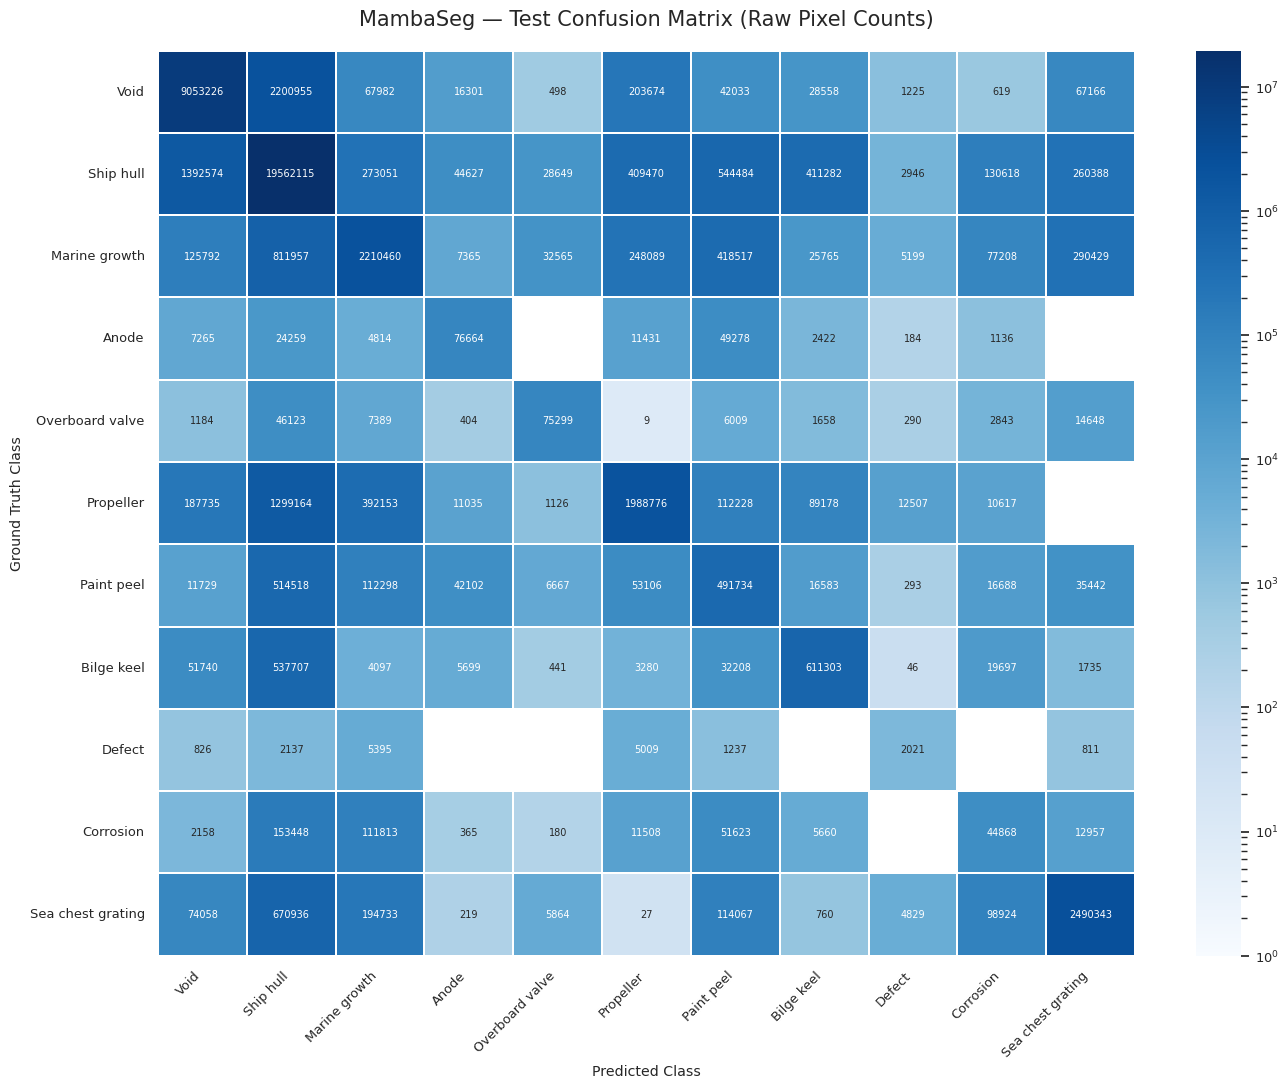

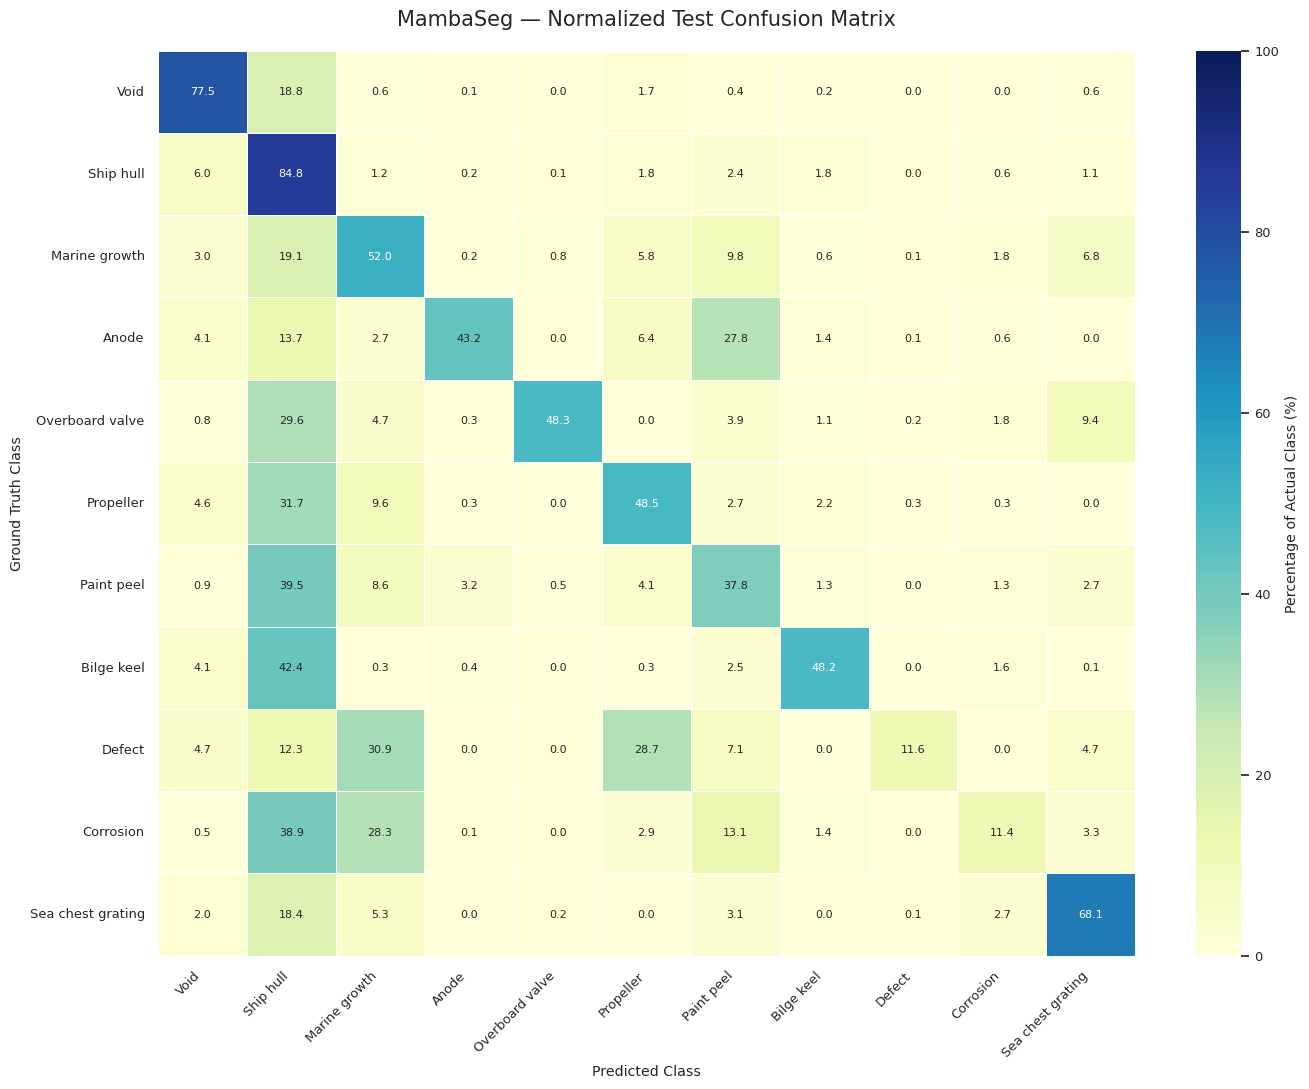

CONFUSION MATRIX ANALYSIS COMPLETE
Raw matrix saved       : /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/results/confusion_matrix_raw.png
Normalized matrix saved: /content/drive/MyDrive/PEP_SEG_DATA/MambaSeg Model/results/confusion_matrix_normalized.png

CRITICAL CLASS RECALL
Paint peel     : 37.79%
Defect         : 11.59%
Corrosion      : 11.37%

✓ CONFUSION MATRICES GENERATED


In [63]:
# ============================================================
# CELL 47 — CONFUSION MATRIX VISUALIZATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

cm_path = os.path.join(
    RESULTS_DIR, "test_confusion_matrix.npy"
)

cm = np.load(cm_path).astype(np.float64)

assert cm.shape == (NUM_CLASSES, NUM_CLASSES)

# Normalize each ground-truth class separately
row_totals = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(cm),
    where=row_totals != 0
)

sns.set_theme(style="white", font_scale=0.85)

# ------------------------------------------------------------
# 1. Raw confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    norm=LogNorm(vmin=1, vmax=max(cm.max(), 1)),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3,
    annot_kws={"size": 7},
    ax=ax
)

ax.set_title(
    "MambaSeg — Test Confusion Matrix (Raw Pixel Counts)",
    fontsize=15,
    pad=18
)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Ground Truth Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

raw_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix_raw.png"
)

plt.savefig(raw_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ------------------------------------------------------------
# 2. Normalized confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    cm_normalized * 100,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.4,
    annot_kws={"size": 8},
    cbar_kws={"label": "Percentage of Actual Class (%)"},
    ax=ax
)

ax.set_title(
    "MambaSeg — Normalized Test Confusion Matrix",
    fontsize=15,
    pad=18
)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Ground Truth Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

normalized_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix_normalized.png"
)

plt.savefig(
    normalized_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 3. Save normalized matrix for later analysis
# ------------------------------------------------------------

np.save(
    os.path.join(
        RESULTS_DIR,
        "test_confusion_matrix_normalized.npy"
    ),
    cm_normalized
)

print("=" * 65)
print("CONFUSION MATRIX ANALYSIS COMPLETE")
print("=" * 65)

print("Raw matrix saved       :", raw_path)
print("Normalized matrix saved:", normalized_path)

print("\nCRITICAL CLASS RECALL")

for class_idx in [6, 8, 9]:
    print(
        f"{CLASS_NAMES[class_idx]:15s}: "
        f"{cm_normalized[class_idx, class_idx] * 100:.2f}%"
    )

print("\n✓ CONFUSION MATRICES GENERATED")

visualisation